In [7]:
# basic notebook for plotting logos from annotated seqlets for highlighting specific examples #

In [1]:
# import packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import torch
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
import logomaker

In [2]:
# define a function for reading in data and concatenating #
def read_in_sat_mut (path2satmut, chunksize):
    # define a list for concatenating #
    chunks2cat = []
    # iterate through chunked tsv #
    for chunk in tqdm(pd.read_csv(path2satmut, sep = '\t', chunksize=chunksize)):
        chunks2cat.append(chunk)
    # concatenate chunks #
    cat_df = pd.concat(chunks2cat)
    return cat_df

In [3]:
def plot_specific_enhancers(enhancer_id,
                            enhStart,
                            chrom,
                            collapsedSeqletBED,
                            LeadVar,
                            otherVars,
                            cell,
                            output):
    # define highlight color
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    
    # load the tensors
    plotLogo_tensors = torch.load(f'/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/{chrom}_plotLogo_tensors.pt')
    
    # get the seqlets for the BED file
    enhBED = collapsedSeqletBED[collapsedSeqletBED['enhancer_id'] == enhancer_id]
    
    # pull the tensors for the enhancer for that cell type
    tensors2plot = plotLogo_tensors[cell][enhancer_id]
    
    # get the max/min attributions for highlighting seqlets
    minAttrib = tensors2plot.min().min() * 1.05
    maxAttrib = tensors2plot.max().max() * 1.05
    
    # build the DF for plotting with logomaker
    dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy()
    renamedDF = dfFromTensor.rename(columns={0: 'A', 1: 'C', 2: 'G', 3: 'T'})
    
    # remove zero-padded positions at ends
    renamedDF = renamedDF.loc[renamedDF.sum(axis=1) != 0]
    
    # adjust enhStart to account for left padding, then reset index to start at 0
    enhStart = enhStart + renamedDF.index[0]
    renamedDF = renamedDF.reset_index(drop=True)
    seq_length = len(renamedDF)
    
    # set plot parameters
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    matplotlib.rcParams['figure.dpi'] = 300
    
    # generate base plot with extra space for annotations
    fig, ax = plt.subplots(figsize=[20, 2.5])
    logoCheck = logomaker.Logo(renamedDF, ax=ax)
    
    # set y-limits based on data only
    logoCheck.ax.set_ylim(minAttrib, maxAttrib)
    
    # track annotation positions to avoid collisions
    top_annotations = []
    bottom_annotations = []
    min_spacing = 3
    
    def get_annotation_level(x_center, text_half_width, existing_annotations):
        """Find the lowest level where this annotation won't overlap with others."""
        level = 0
        while True:
            conflict = False
            for other_center, other_half_width, other_level in existing_annotations:
                if other_level == level:
                    distance = abs(x_center - other_center)
                    min_dist = text_half_width + other_half_width + min_spacing
                    if distance < min_dist:
                        conflict = True
                        break
            if not conflict:
                return level
            level += 1
    
    # highlight seqlets and collect annotation info
    for idx, row in enhBED.iterrows():
        start, stop, actClass, tf = row[['start', 'end', 'activity_class', 'tf_family']].tolist()
        start = int(start - enhStart)
        stop = int(stop - enhStart - 1)
        x_center = (stop + start) / 2
        x_center_norm = x_center / seq_length  # normalize to 0-1 for axes coords
        tf_label = tf.split('_')[0]
        text_half_width = len(tf_label) * 2.5
        
        if actClass == 'Activator':
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', floor=0)
            
            level = get_annotation_level(x_center, text_half_width, top_annotations)
            top_annotations.append((x_center, text_half_width, level))
            
            # draw bracket line in data coords
            #bracket_y = maxAttrib * 1.05 + level  # above the y-limit
            #ax.plot([start, stop], [bracket_y, bracket_y], color='k', linewidth=1, solid_capstyle='butt', clip_on=False)
            
            # annotate in axes coords (outside plot area)
            y_offset = 1.05 + level * 0.05
            ax.annotate(tf_label,
                        xy=(x_center_norm, 1.0),  # anchor at top of axes
                        xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset),
                        textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='bottom',
                        annotation_clip=False)
        else:
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', ceiling=0)
            
            level = get_annotation_level(x_center, text_half_width, bottom_annotations)
            bottom_annotations.append((x_center, text_half_width, level))
            
            # draw bracket line in data coords
            #bracket_y = minAttrib * 1.05 + level  # below the y-limit (more negative)
            #ax.plot([start, stop], [bracket_y, bracket_y], color='k', linewidth=1, solid_capstyle='butt', clip_on=False)
            
            # annotate in axes coords (outside plot area)
            y_offset = -0.01 - level * 0.12
            ax.annotate(tf_label,
                        xy=(x_center_norm, 0.0),  # anchor at bottom of axes
                        xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset),
                        textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='top',
                        annotation_clip=False)
    
    # highlight lead Variant
    LeadVar = int(LeadVar - enhStart - 1)
    logoCheck.highlight_position(p=LeadVar, color='red', alpha=0.5, floor=0)
    
    # highlight larger effect variants
    for var in otherVars:
        var2plot = int(var - enhStart - 1)
        logoCheck.highlight_position(p=var2plot, color='deepskyblue', alpha=0.25, floor=0)
    
    logoCheck.style_spines(visible=False)
    
    # set x-axis ticks to genomic positions at 50bp intervals
    first_tick_genomic = ((enhStart // 50) + 1) * 50
    tick_positions = []
    tick_labels = []
    
    for genomic_pos in range(first_tick_genomic, enhStart + seq_length, 50):
        plot_pos = genomic_pos - enhStart
        if 0 <= plot_pos < seq_length:
            tick_positions.append(plot_pos)
            tick_labels.append(str(genomic_pos))
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', length=5, pad=5)

    first_minor_genomic = ((enhStart // 10) + 1) * 10
    first_major_genomic = ((enhStart // 50) + 1) * 50

    major_tick_positions = []
    major_tick_labels = []
    minor_tick_positions = []

    for genomic_pos in range(first_minor_genomic, enhStart + seq_length, 10):
        plot_pos = genomic_pos - enhStart - 1
        if 0 <= plot_pos < seq_length:
            if genomic_pos % 50 == 0:  # major tick
                major_tick_positions.append(plot_pos)
                major_tick_labels.append(str(genomic_pos))
            else:  # minor tick
                minor_tick_positions.append(plot_pos)

    ax.set_xticks(major_tick_positions)
    ax.set_xticklabels(major_tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', length=5, pad=5)

    ax.set_xticks(minor_tick_positions, minor=True)
    ax.tick_params(axis='x', which='minor', length=2.5)
    
    plt.title(f'{enhancer_id} | {cell}', loc='left')
    
    # adjust subplot to make room for annotations
    plt.subplots_adjust(top=0.75, bottom=0.25)

In [4]:
# define function for reformatting collapsed mpac seqlet calls:
def mpac_collapsed_dels (path2bed,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    filtered_bed = bed.copy()
    # Use column 5 (rep_tf) which has the TF with highest |contribution| for multi-TF intervals
    # Try multiple HOCOMOCO suffixes since they vary (.A, .B, .C, .D)
    def get_tf_family(rep_tf, motif_dict):
        for suffix in ['.A', '.B', '.C', '.D']:
            key = f"{rep_tf}_HUMAN.H11MO.0{suffix}"
            if key in motif_dict:
                return motif_dict[key]
        return None
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : filtered_bed[5],  # Use pre-computed rep_tf from column 5
                             'tf_family' : [get_tf_family(tf, motif_dict) for tf in filtered_bed[5]],
                             'activity_class' : filtered_bed[6],
                             'enhancer_id' : filtered_bed[7]})
    return bed2plot

In [5]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [6]:
# reformat MPAC collapsed BED files
path2beds = '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/bed_files'
# k562
k_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_k562_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)
# hepg2
h_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_hepg2_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)
# sknsh
s_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/repTF_sknsh_dELS_seqlets_01.bed',
                                            vierstra_motif_dict)

In [7]:
### K562 GWAS HIGH DELTAS ###

In [ ]:
enhancer_id,
                            enhStart,
                            chrom,
                            collapsedSeqletBED,
                            LeadVar,
                            otherVars,
                            cell,
                            output

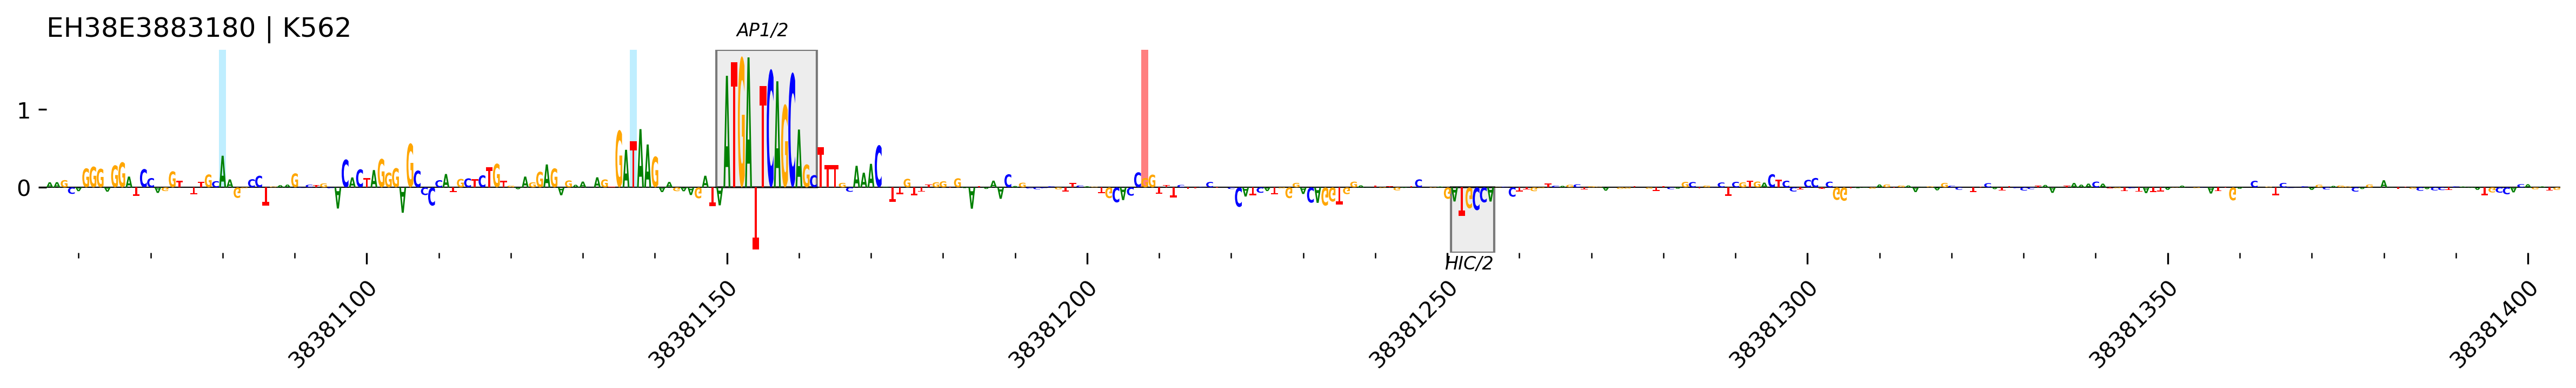

In [9]:
plot_specific_enhancers(
    'EH38E3883180',
    38381055,
    'chr9',
    k_mpac_collapsed_dels,
    38381208,
    [38381080,38381137],
    'K562',
    ''
)

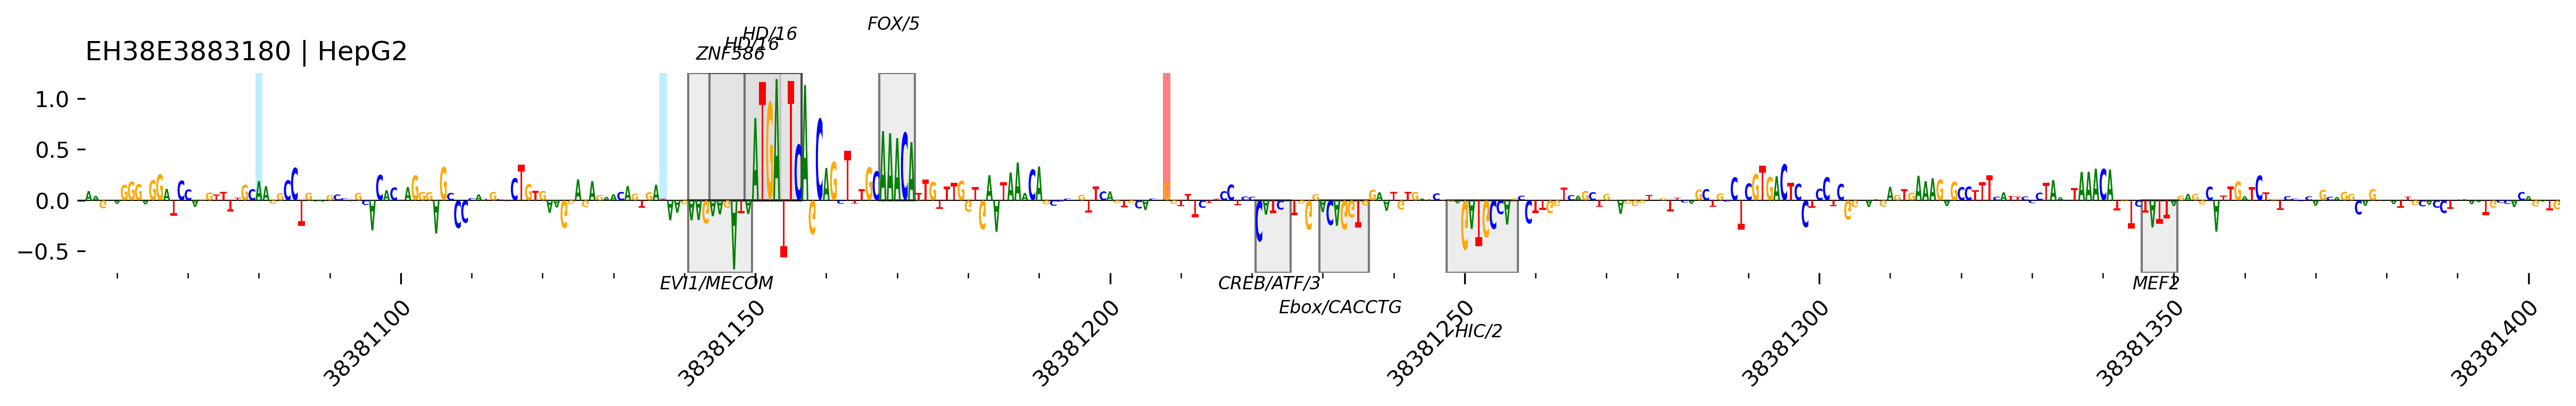

In [10]:
plot_specific_enhancers(
    'EH38E3883180',
    38381055,
    'chr9',
    h_mpac_collapsed_dels,
    38381208,
    [38381080,38381137],
    'HepG2',
    ''
)

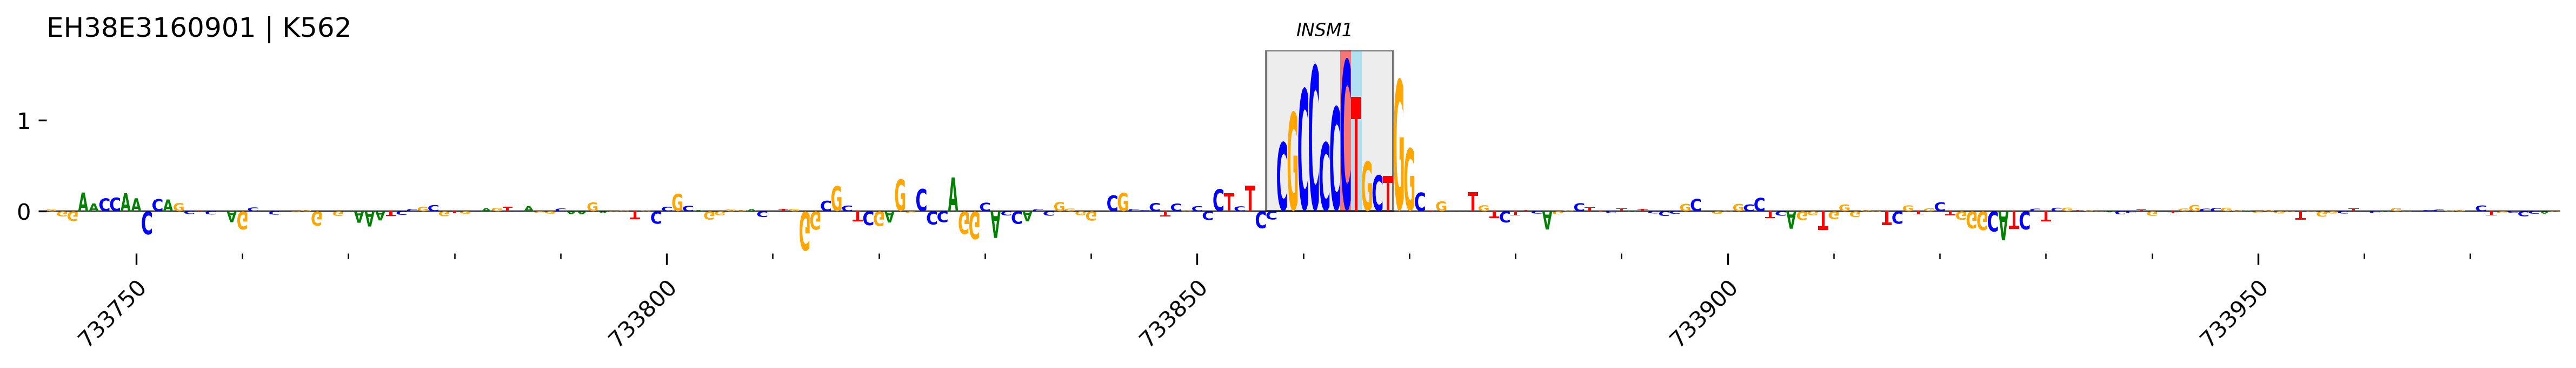

In [9]:
plot_specific_enhancers(
    'EH38E3160901',
    733741,
    'chr16',
    k_mpac_collapsed_dels,
    733864,
    [733865],
    'K562',
    'x'
)

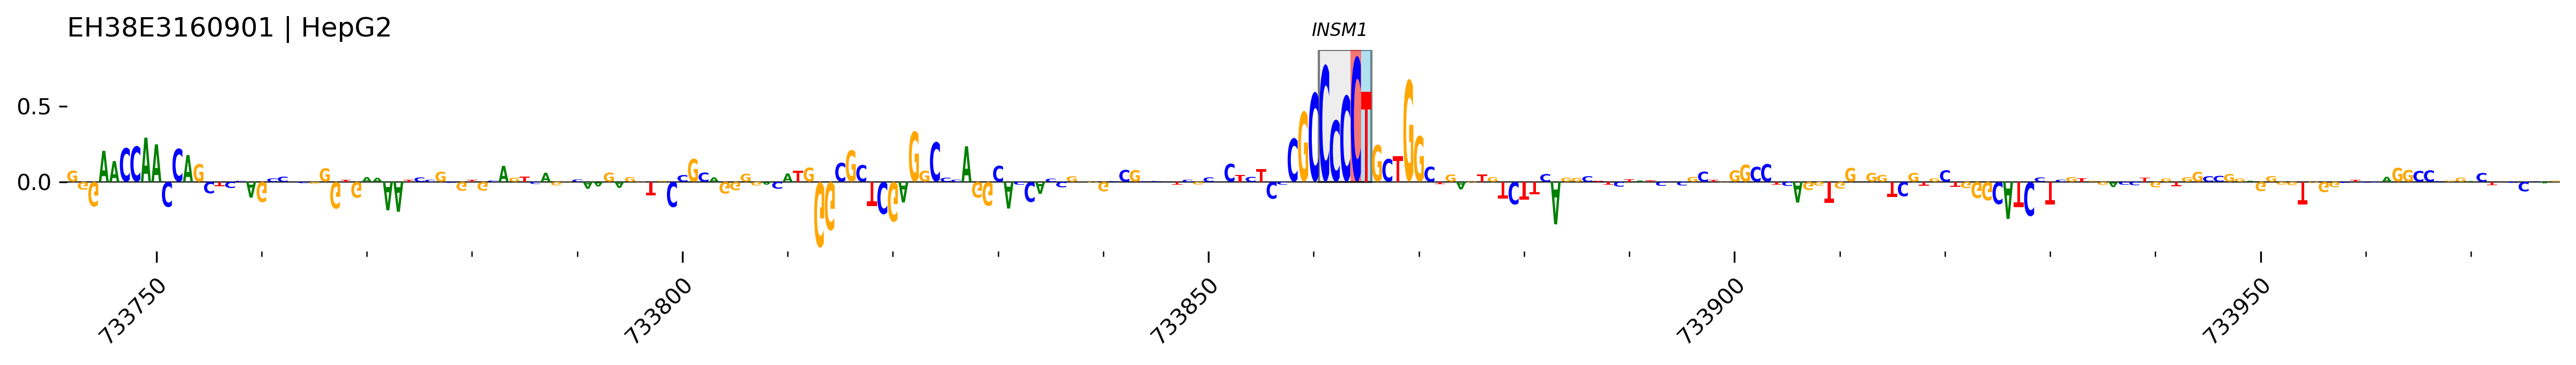

In [10]:
plot_specific_enhancers(
    'EH38E3160901',
    733741,
    'chr16',
    h_mpac_collapsed_dels,
    733864,
    [733865],
    'HepG2',
    'x'
)

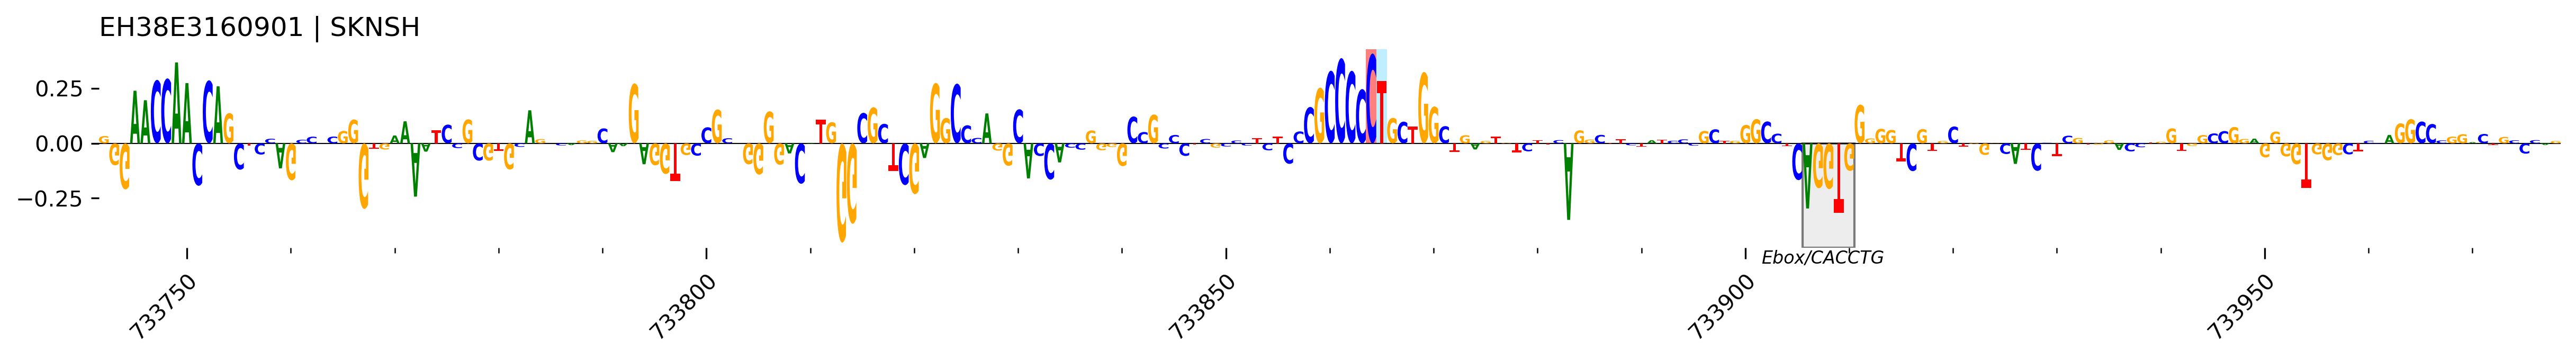

In [11]:
plot_specific_enhancers(
    'EH38E3160901',
    733741,
    'chr16',
    s_mpac_collapsed_dels,
    733864,
    [733865],
    'SKNSH',
    'x'
)

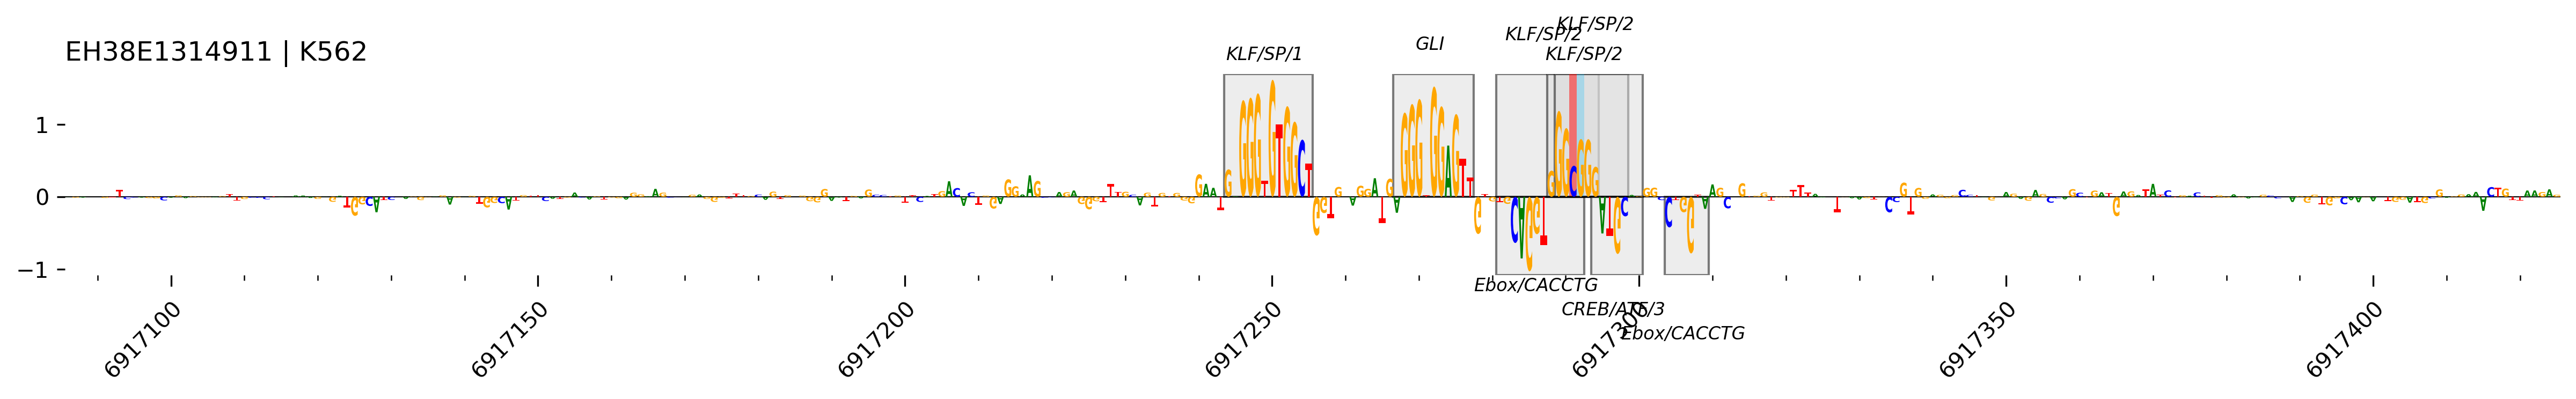

In [25]:
# EH38E1314911 GWAS variant
# chr1:6,917,085-6,917,425
# high delta lead variant
# identified in K562
# Ebox/CACCCTG motif
# 'Personal history of allergy to medicinal agents (PheCode 977)'
plot_specific_enhancers(
    'EH38E1314911',
    6917085,
    'chr1',
    k_mpac_collapsed_dels,
    6917291,
    [6917292],
    'K562',
    'x'
)

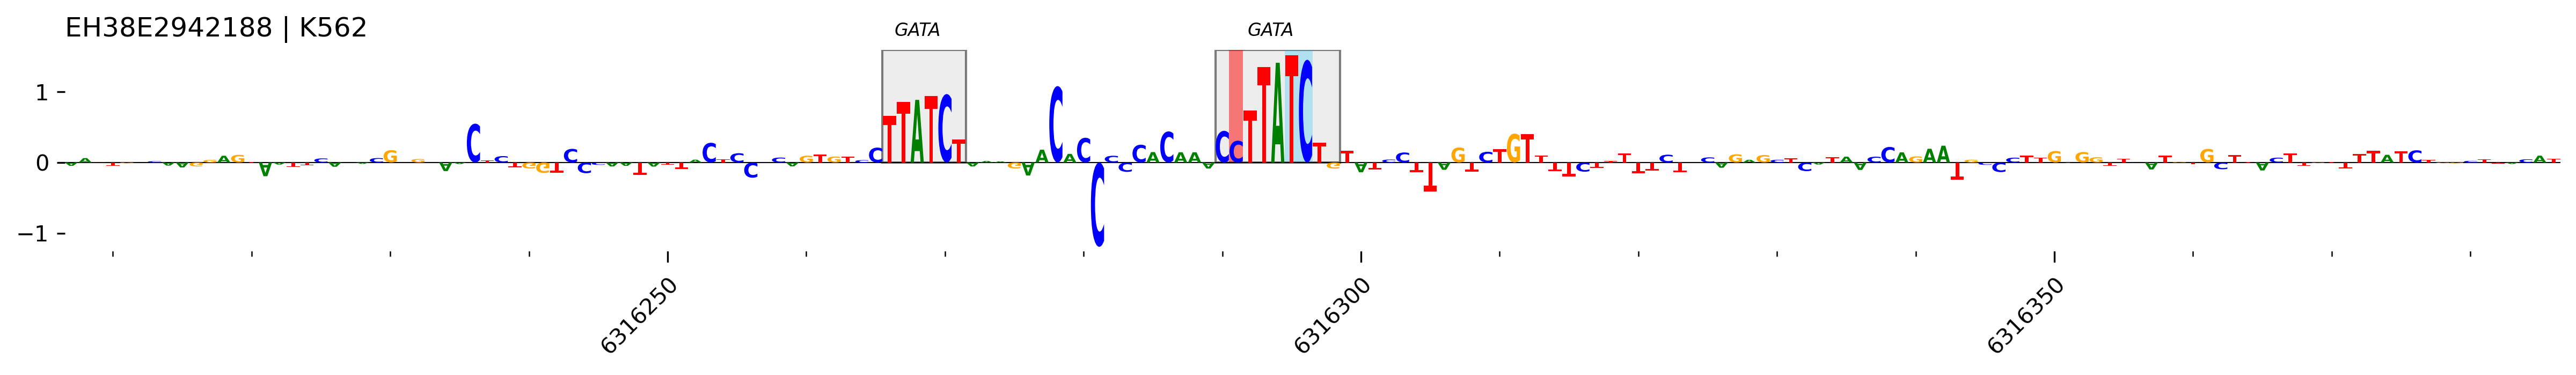

In [26]:
# EH38E2942188 GWAS variant
# chr11:6,316,206-6,316,386
# high delta lead variant
# identified in K562
# 'Platelet endothelial cell adhesion molecule protein level'
# identified in GATA motif
plot_specific_enhancers(
    'EH38E2942188',
    6316206,
    'chr11',
    k_mpac_collapsed_dels,
    6316291,
    [6316295, 6316296],
    'K562',
    'x'
)

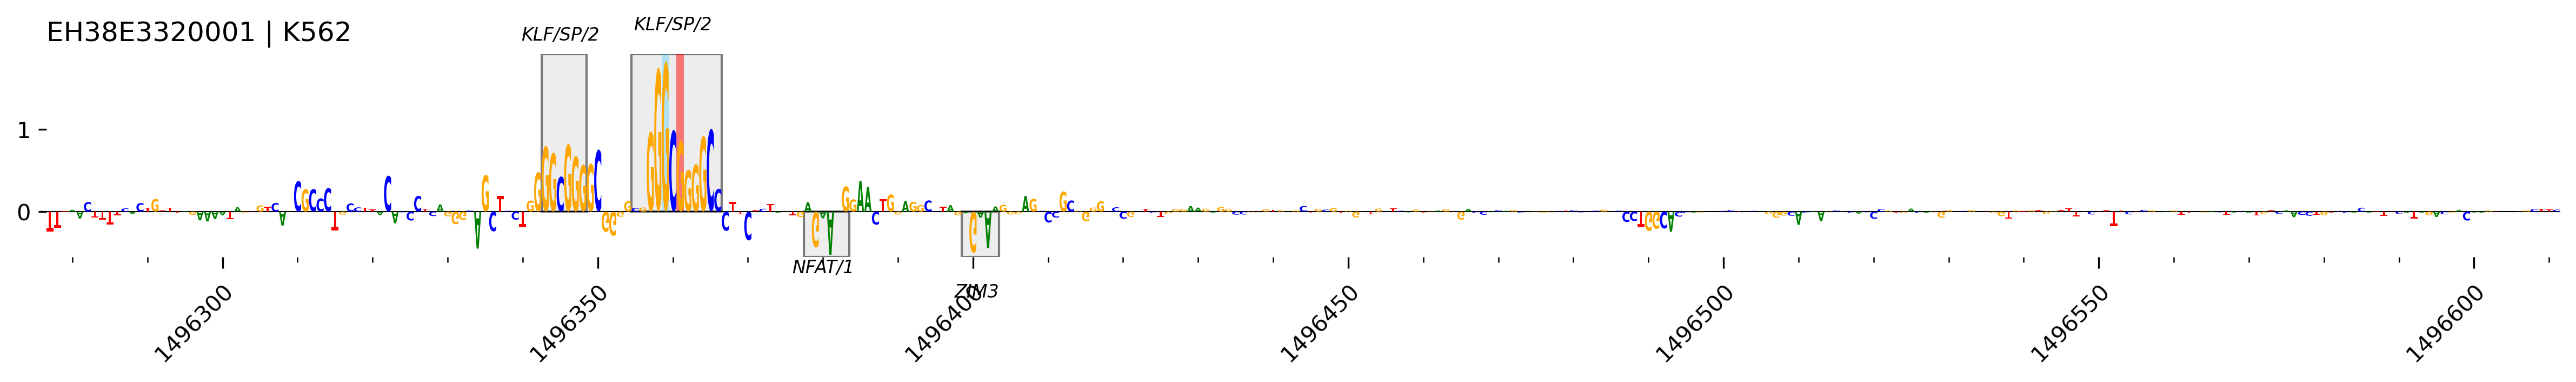

In [27]:
# EH38E3320001
# chr2:1,496,276-1,496,611
# high delta lead variant
# 'Benign neoplasm of lip, oral cavity, and pharynx (PheCode 210)'
plot_specific_enhancers(
    'EH38E3320001',
    1496276,
    'chr2',
    k_mpac_collapsed_dels,
    1496361,
    [1496359],
    'K562',
    'x'
)

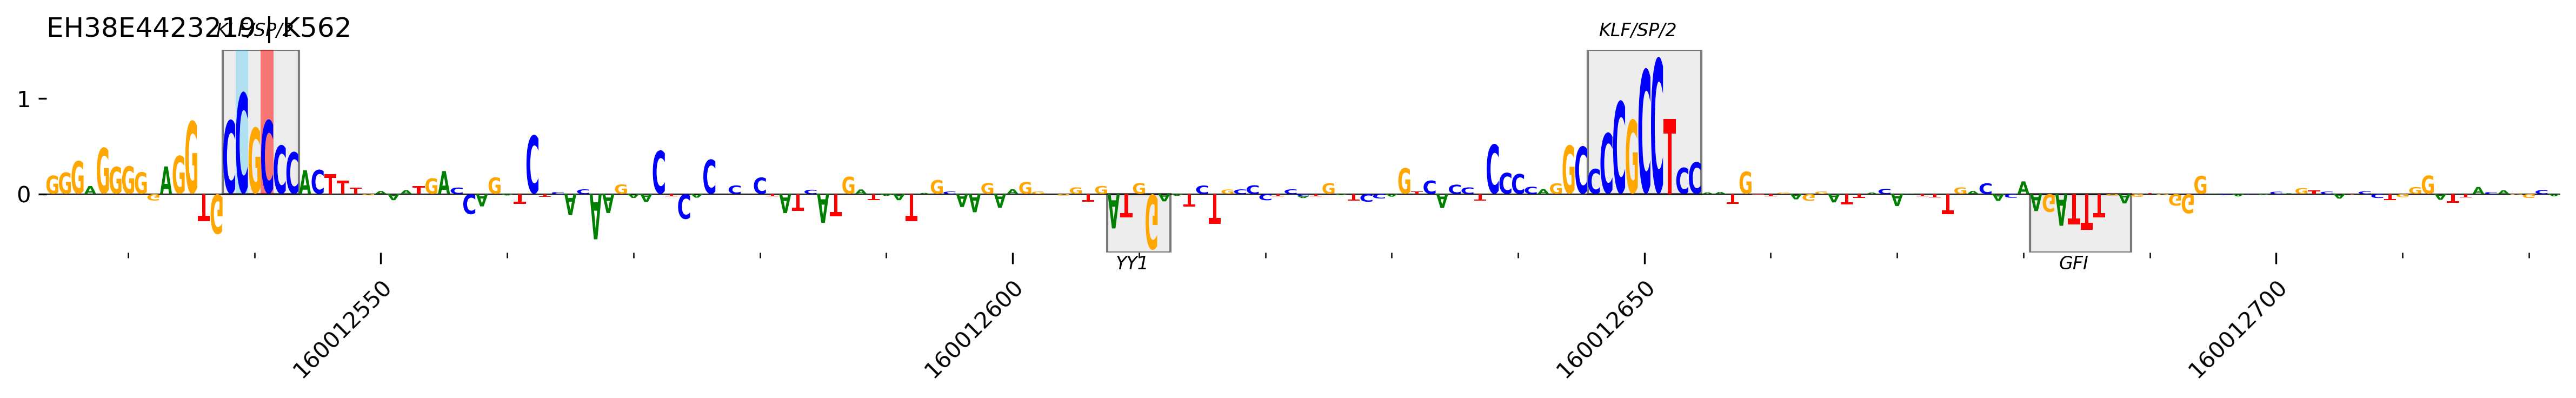

In [28]:
# EH38E4423219
# chr6:160,012,523-160,012,722
# 'Benign neoplasm of lip, oral cavity, and pharynx (PheCode 210)'
## DOUBLE CHECK SEQLET ANNOTATIONS ##
plot_specific_enhancers(
    'EH38E4423219',
    160012523,
    'chr6',
    k_mpac_collapsed_dels,
    160012541,
    [160012539],
    'K562',
    'x'
)

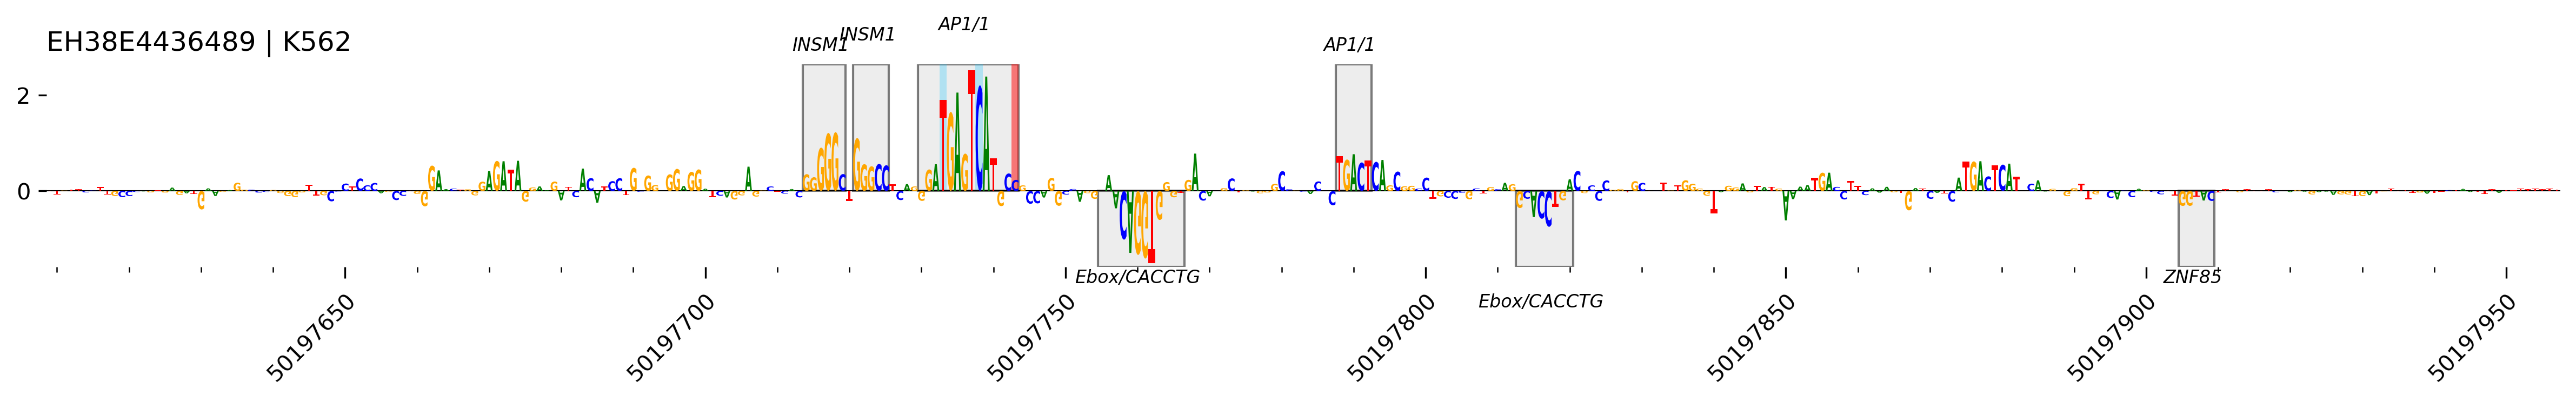

In [24]:
# EH38E4436489
# chr7:50,197,608-50,197,957
# 'Serine/threonine-protein phosphatase 2A 56 kDa regulatory subunit alpha isoform protein level'
plot_specific_enhancers(
    'EH38E4436489',
    50197608,
    'chr7',
    k_mpac_collapsed_dels,
    50197743,
    [50197733, 50197738],
    'K562',
    'x'
)

In [21]:
### HEPG2 HIGH DELTAS ###

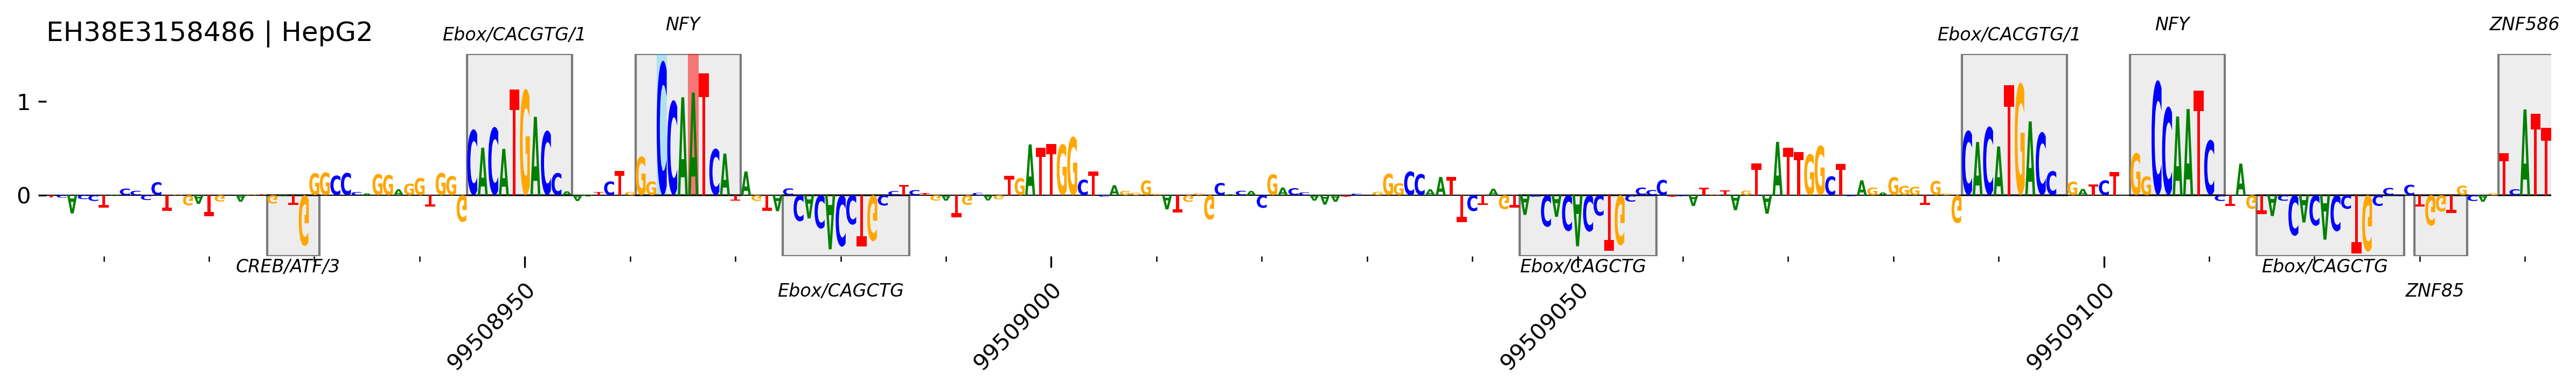

In [29]:
# EH38E3158486
# chr15:99,508,904-99,509,142
# lead Delta: 0.55
# 'ICD10 E28.3: Primary ovarian failure'
plot_specific_enhancers(
    'EH38E3158486',
    99508904,
    'chr15',
    h_mpac_collapsed_dels,
    99508966,
    [99508963],
    'HepG2',
    'x'
)

In [30]:
### SKNSH HIGH DELTAS ###

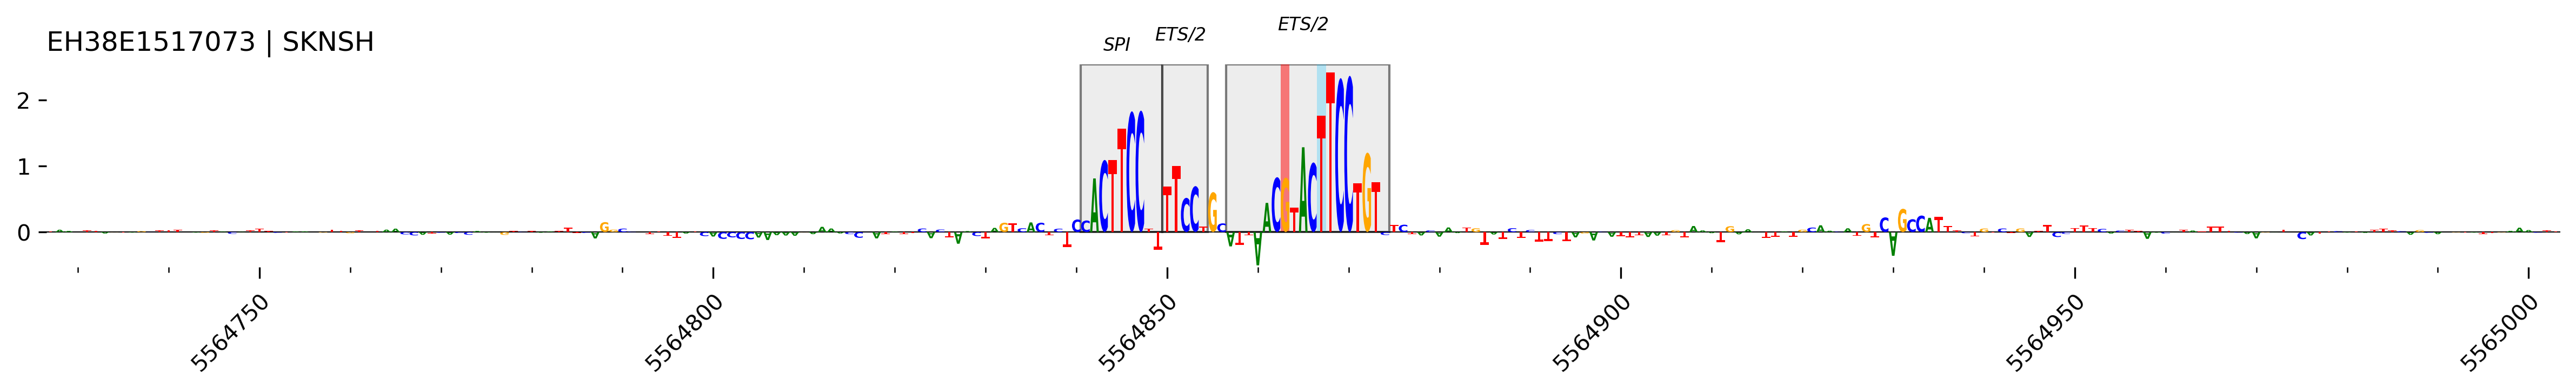

In [31]:
# EH38E1517073
# chr11:5,564,726-5,565,003
# lead delta: 1.38
# 'mean corpuscular hemoglobin (MCH, maximum, inv-norm transformed)'
plot_specific_enhancers(
    'EH38E1517073',
    5564726,
    'chr11',
    s_mpac_collapsed_dels,
    5564863,
    [5564867],
    'SKNSH',
    'x'
)

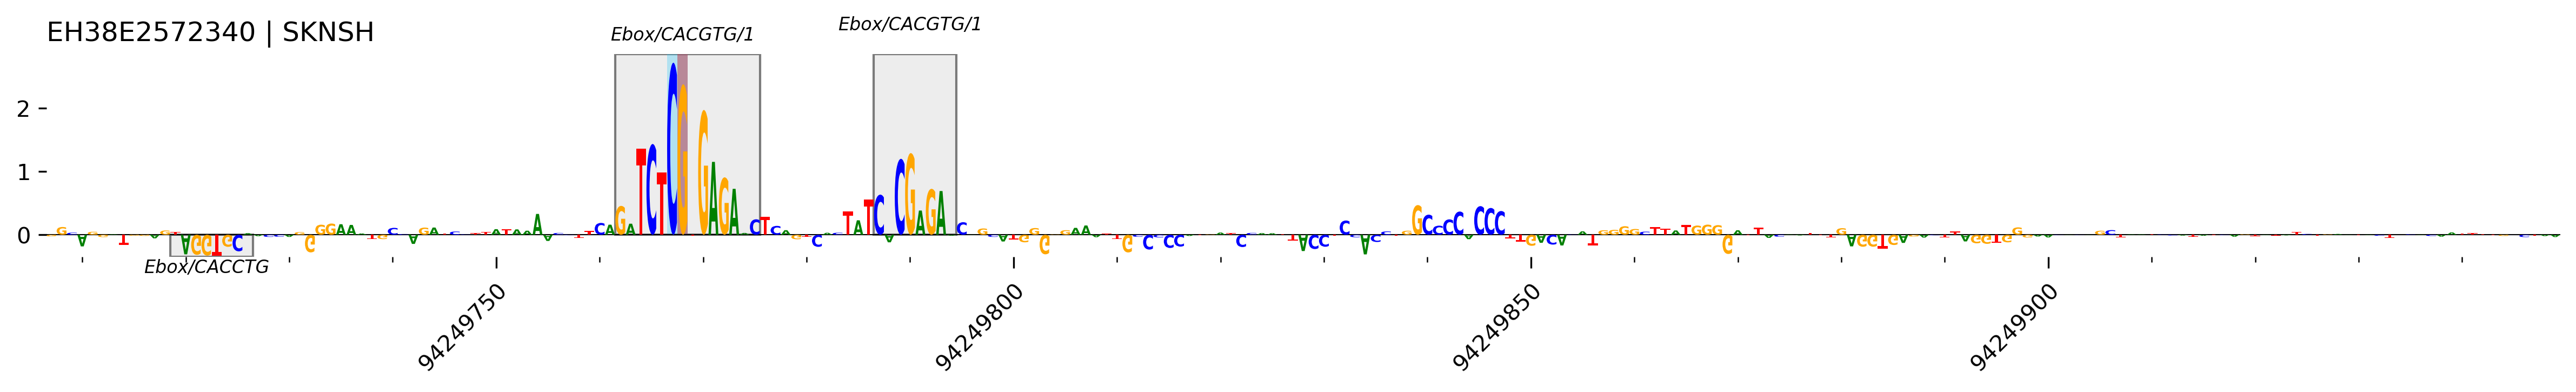

In [32]:
# EH38E2572340
# chr7:94,249,706-94,249,949
# lead delta: 0.75, 0.69
# 'Actin-binding LIM protein 3 protein level'
plot_specific_enhancers(
    'EH38E2572340',
    94249706,
    'chr7',
    s_mpac_collapsed_dels,
    94249768,
    [94249767, 94249768],
    'SKNSH',
    'x'
)

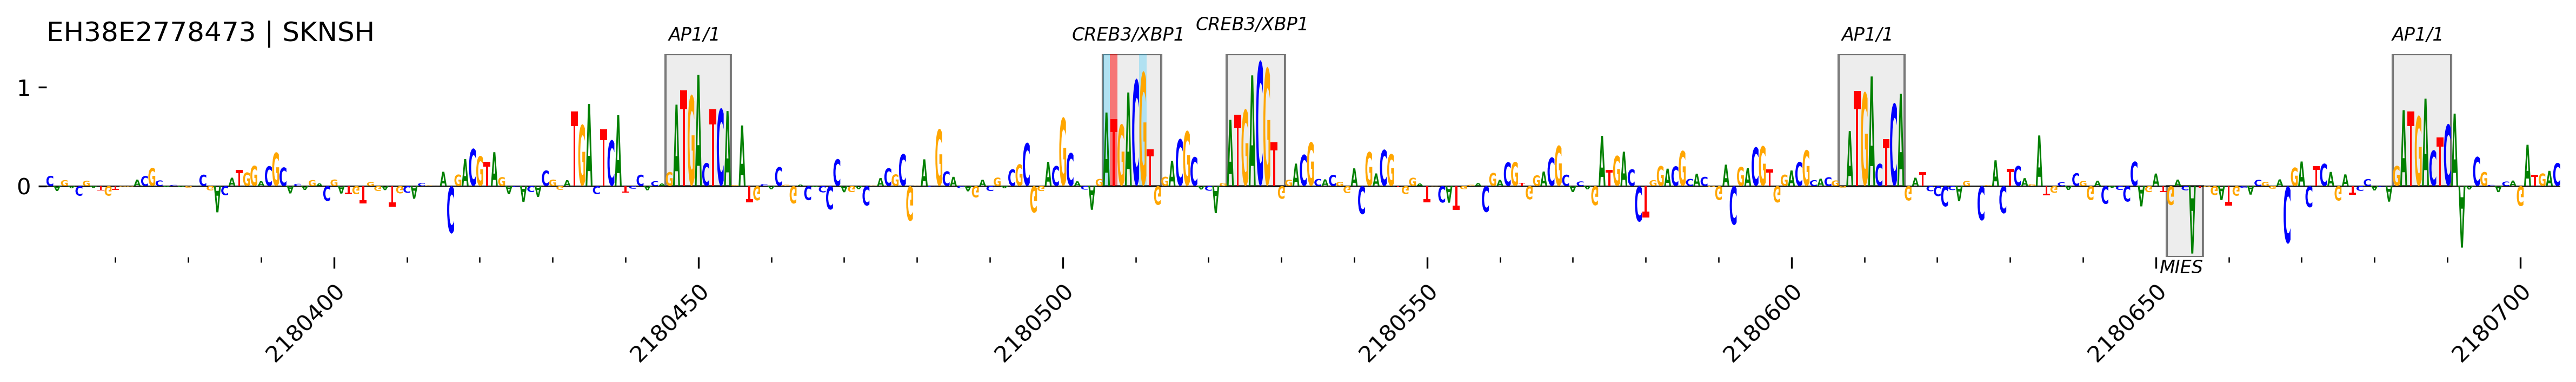

In [33]:
# EH38E2778473
# chr1:2,180,360-2,180,705
# lead Delta: 0.79, 0.6
# 'Hemoglobin A1c (HbA1c, maximum, inv-norm transformed)'
plot_specific_enhancers(
    'EH38E2778473',
    2180360,
    'chr1',
    s_mpac_collapsed_dels,
    2180507,
    [2180506, 2180511],
    'SKNSH',
    'x'
)

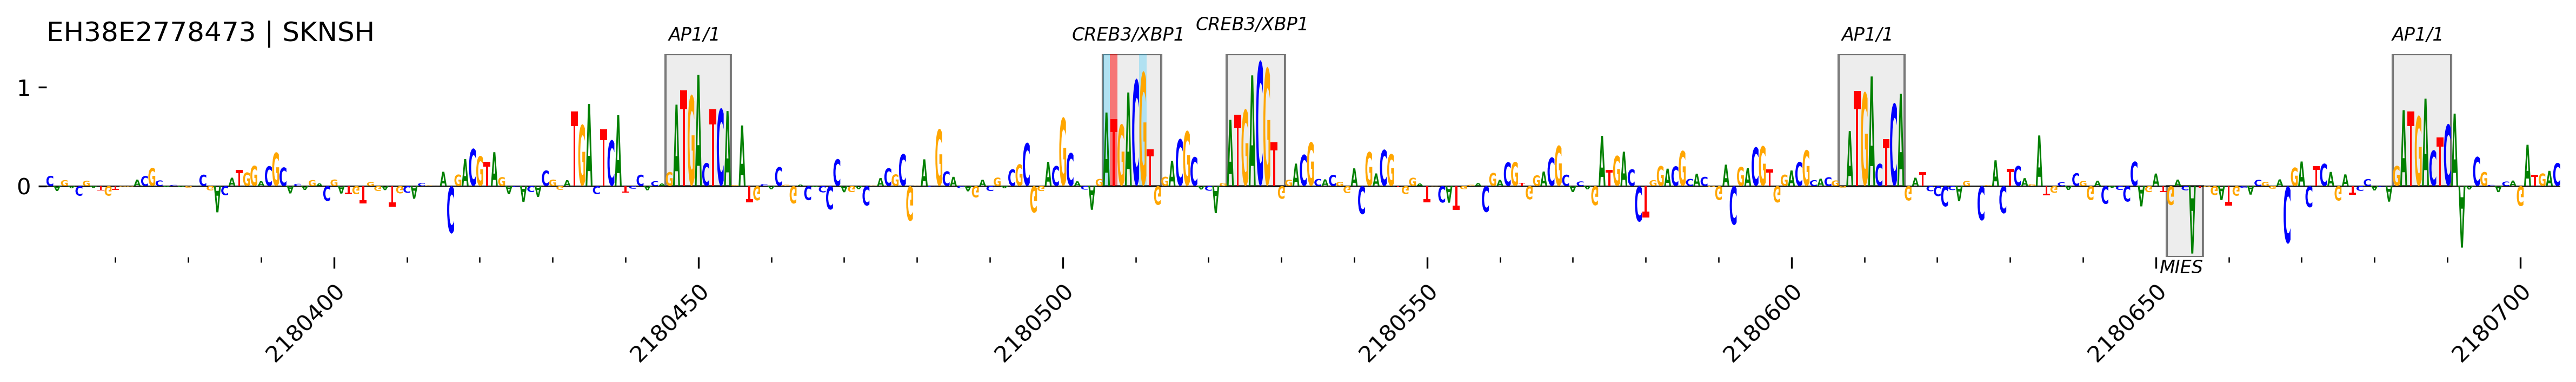

In [34]:
# EH38E2778473
# chr1:2,180,360-2,180,705
# lead Delta: 0.79, 0.6
# 'Hemoglobin A1c (HbA1c, mean, inv-norm transformed)'
plot_specific_enhancers(
    'EH38E2778473',
    2180360,
    'chr1',
    s_mpac_collapsed_dels,
    2180507,
    [2180506, 2180511],
    'SKNSH',
    'x'
)

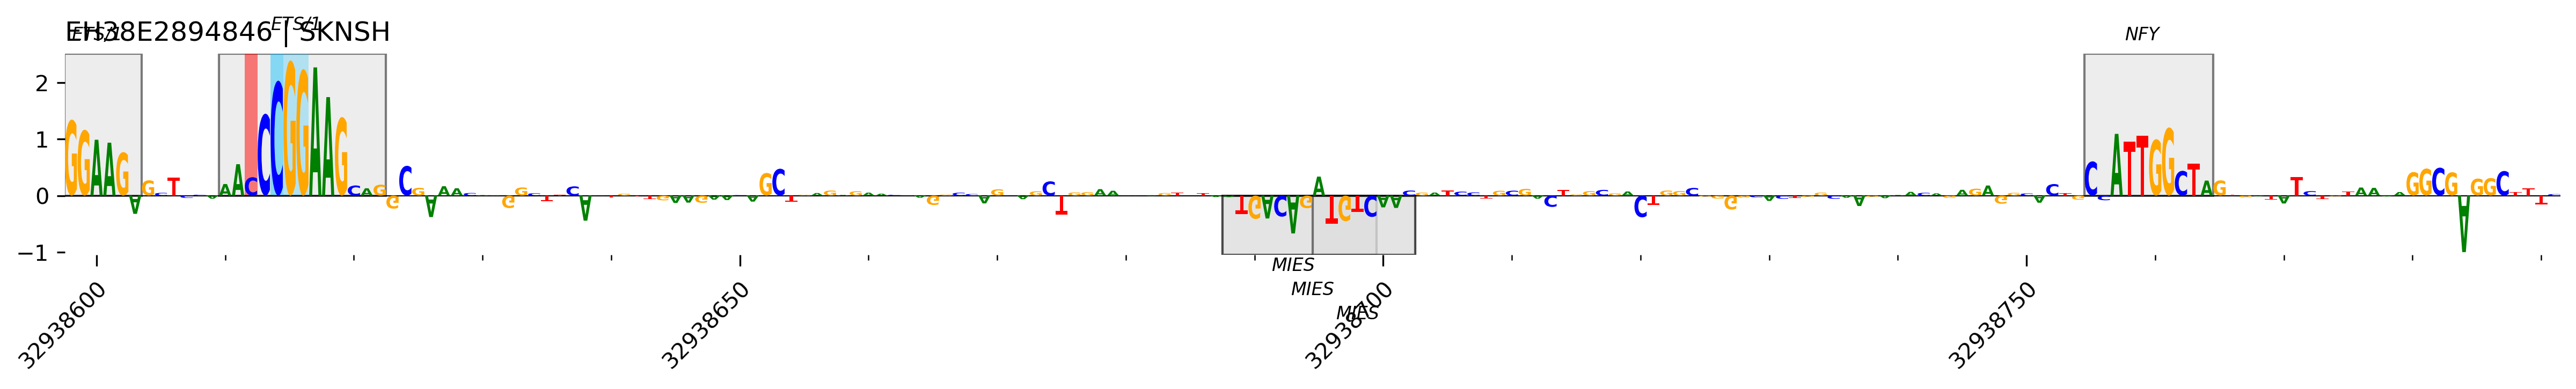

In [35]:
# EH38E2894846
# chr10:32,938,597-32,938,791
# delta Lead: 1.09, 1.53, 1.64, 1.59
# 'Anisometropia (PheCode 368.3)'
plot_specific_enhancers(
    'EH38E2894846',
    32938597,
    'chr10',
    s_mpac_collapsed_dels,
    32938612,
    [32938614, 32938614, 32938615, 32938616],
    'SKNSH',
    'x'
)

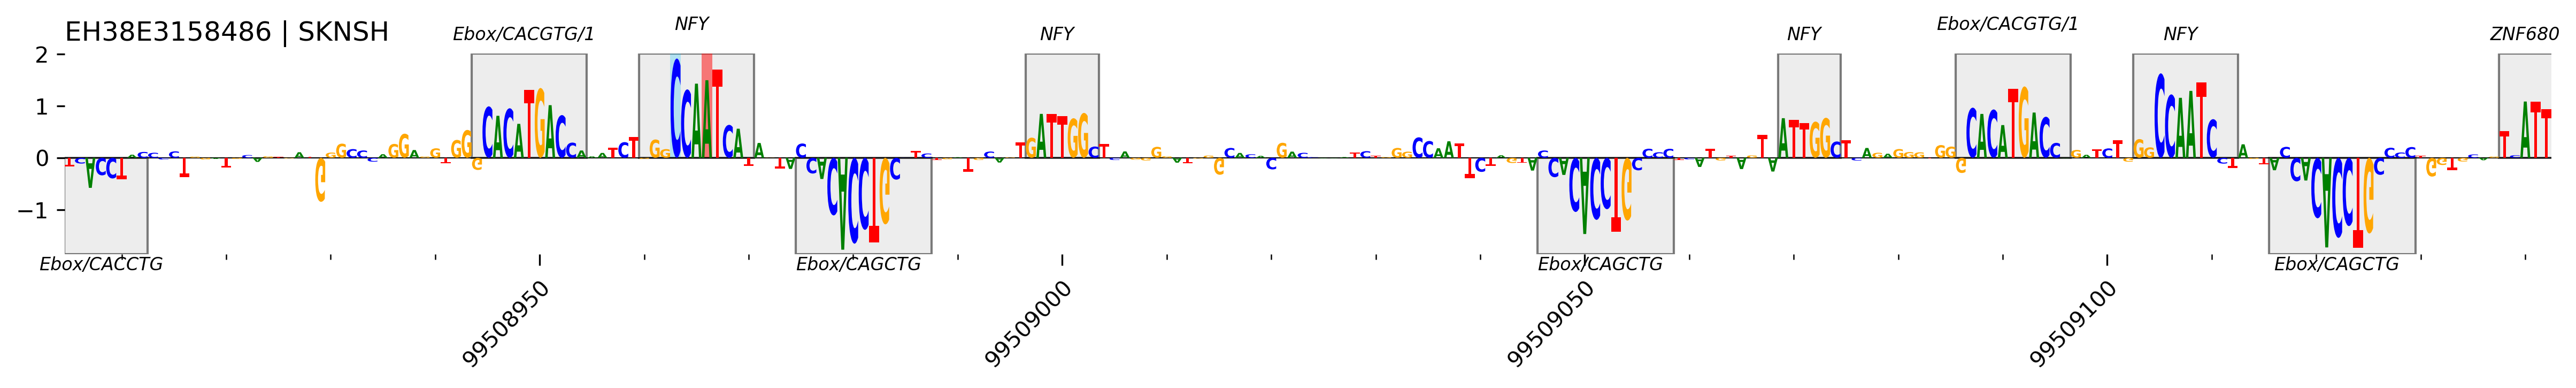

In [36]:
# EH38E3158486
# chr15:99,508,904-99,509,142
# lead Delta: 0.55
# 'ICD10 E28.3: Primary ovarian failure'
plot_specific_enhancers(
    'EH38E3158486',
    99508904,
    'chr15',
    s_mpac_collapsed_dels,
    99508966,
    [99508963],
    'SKNSH',
    'x'
)

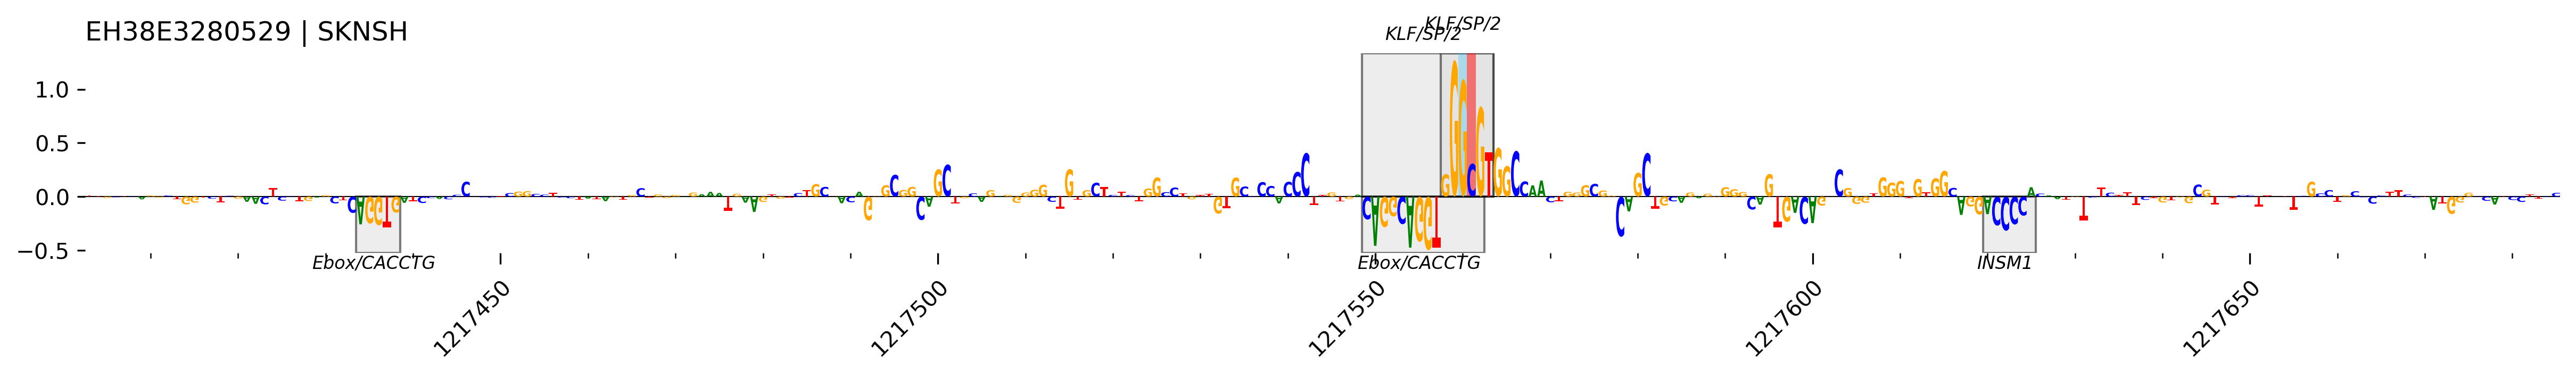

In [37]:
# EH38E3280529
# chr19:1,217,402-1,217,685
# lead Delta: 0.537760
# 'heart rate (HR, mean, inv-normal transformed)'
plot_specific_enhancers(
    'EH38E3280529',
    1217402,
    'chr19',
    s_mpac_collapsed_dels,
    1217561,
    [1217560],
    'SKNSH',
    'x'
)

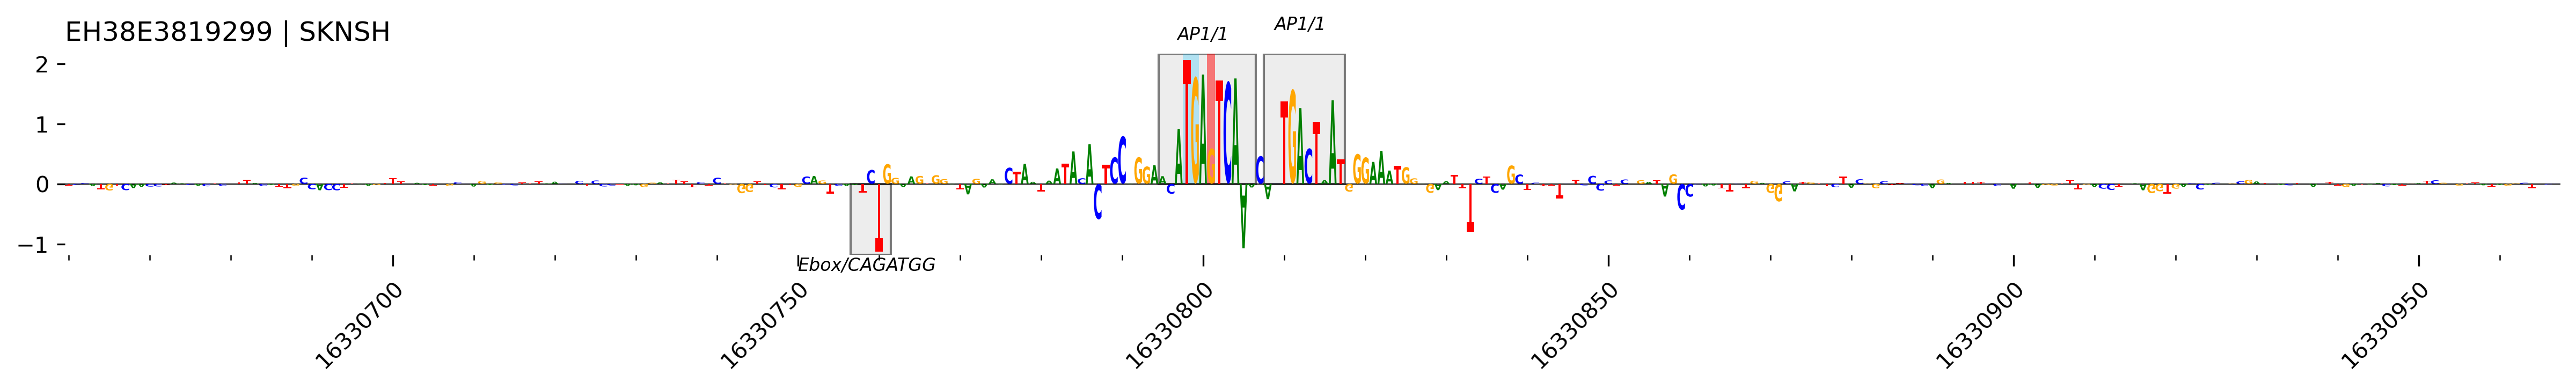

In [38]:
# EH38E3819299
# chr8:16,330,659-16,330,967
# lead Delta: 0.925959, 0.974034
# 'Diabetes mellitus (PheCode 250)'
plot_specific_enhancers(
    'EH38E3819299',
    16330659,
    'chr8',
    s_mpac_collapsed_dels,
    16330801,
    [16330798, 16330799],
    'SKNSH',
    'x'
)

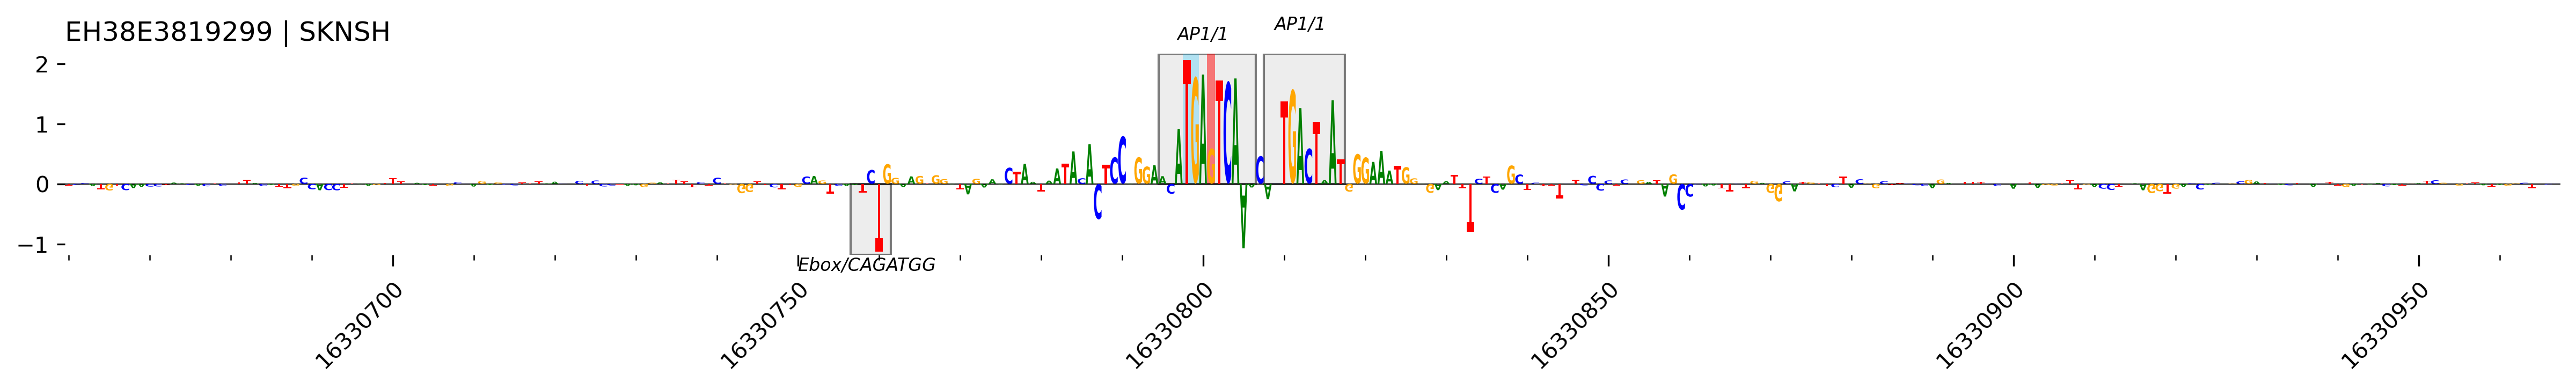

In [39]:
# EH38E3819299
# chr8:16,330,659-16,330,967
# lead Delta: 0.925959, 0.974034
# 'Type 2 diabetes (PheCode 250.2)'
plot_specific_enhancers(
    'EH38E3819299',
    16330659,
    'chr8',
    s_mpac_collapsed_dels,
    16330801,
    [16330798, 16330799],
    'SKNSH',
    'x'
)

In [33]:
### K562 GTEx HIGH DELTAS ###

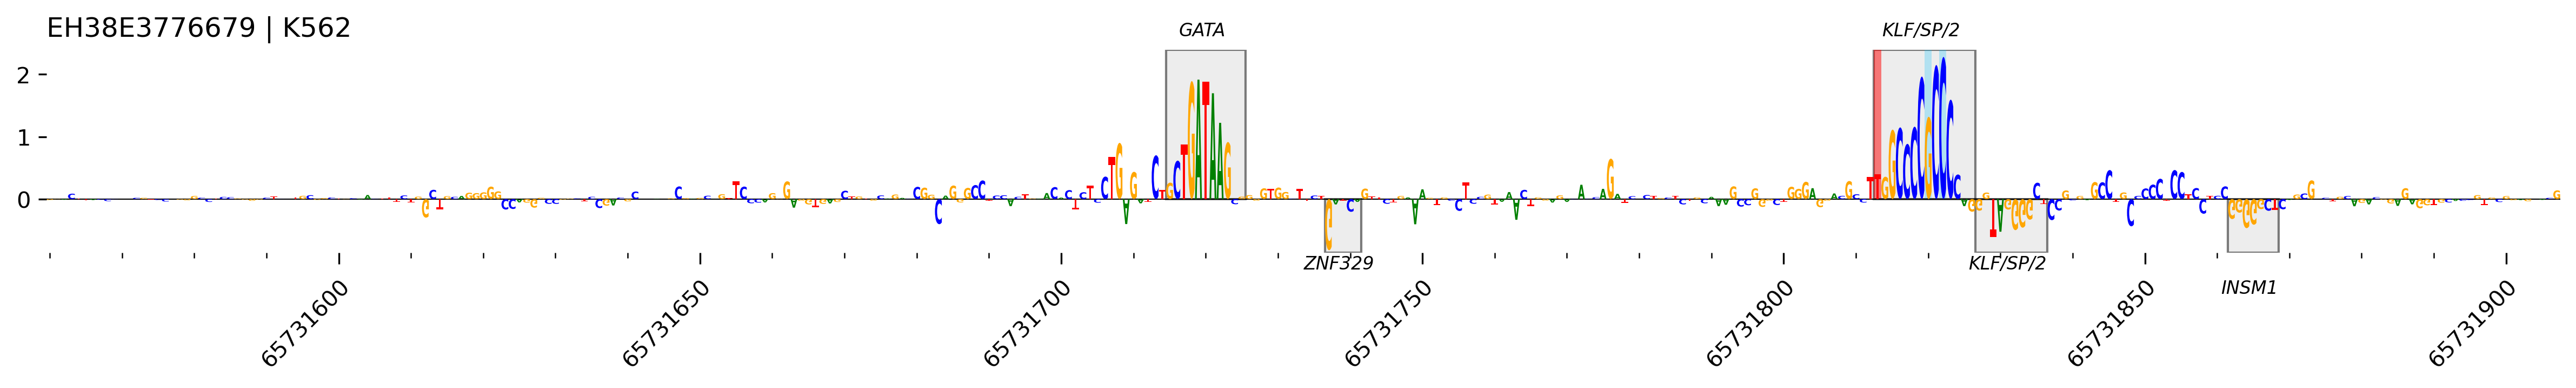

In [40]:
# EH38E3776679
# chr7:65,731,559-65,731,907
# lead Delta: 1.442047, 1.713817
# phenotype id: ENSG00000236529.2
# gene name: ENSG00000236529
# tissue: cells_cultured_fibroblasts
# biotype: lncRNA
plot_specific_enhancers(
    'EH38E3776679',
    65731559,
    'chr7',
    k_mpac_collapsed_dels,
    65731813,
    [65731820, 65731822],
    'K562',
    'x'
)

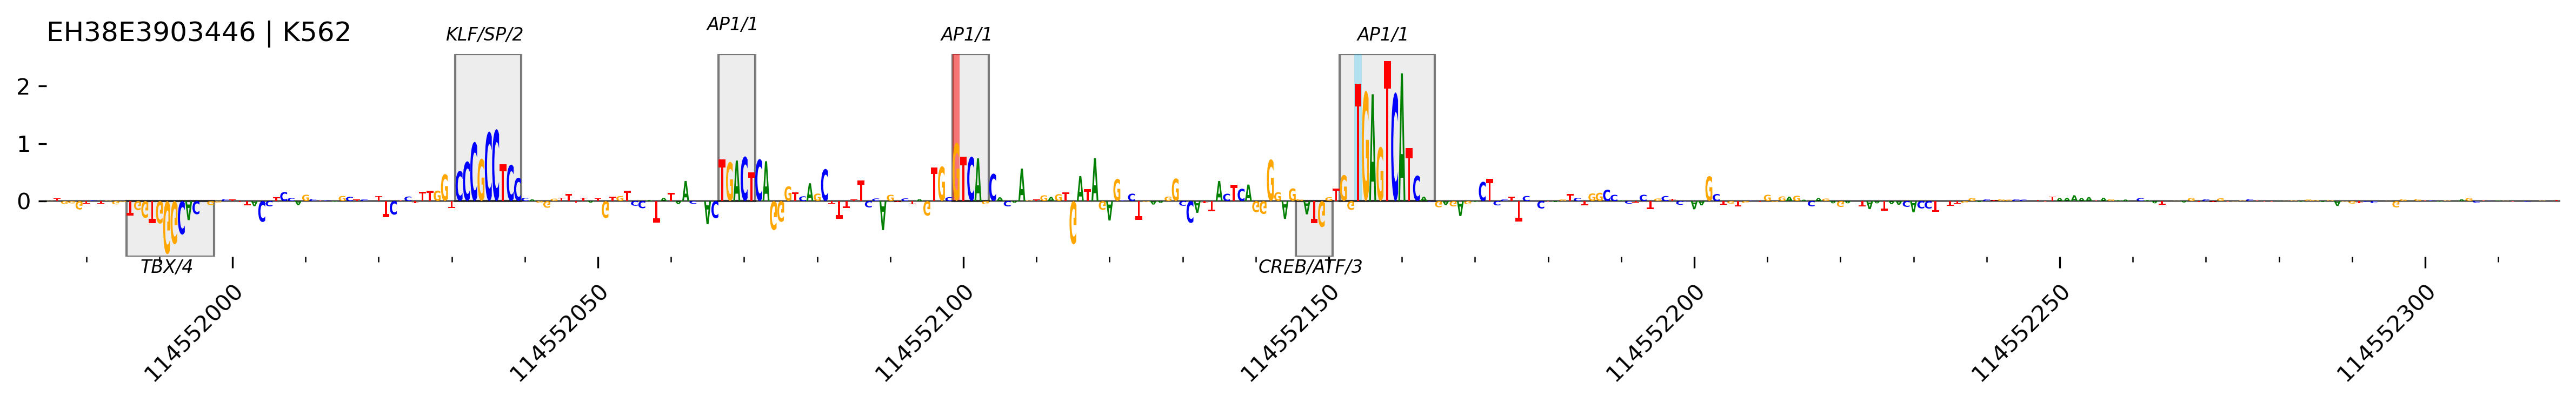

In [41]:
# EH38E3903446
# lead Delta: 1.152007
# phenotype id: ENSG00000095397.16
# gene name: WHRN
# tissue: cells_cultured_fibroblasts
# biotype: protein_coding
plot_specific_enhancers(
    'EH38E3903446',
    114551974,
    'chr9',
    k_mpac_collapsed_dels,
    114552099,
    [114552154],
    'K562',
    'x'
)
# at position 114552098 there is a C instead of an A, weakening the AP/1 motif
# MPAC predicts that C-> to strongly increase expression in all cell types
# chr9	114552098	EH38E3903446	C	A	4.1033745	5.7116165	1.6082418	3.0790224	4.0576935	0.97867095	3.165228	4.289769	1.1245414
# similarly G->T at 114552103 strengthens the motif and predicted to increase expression
# chr9	114552103	EH38E3903446	G	T	4.1975427	4.712678	0.51513535	3.1151578	3.6658368	0.5506788	3.2200916	3.957557	0.7374657
# expressed in K562: 0.9 (log10 TPM + 1)

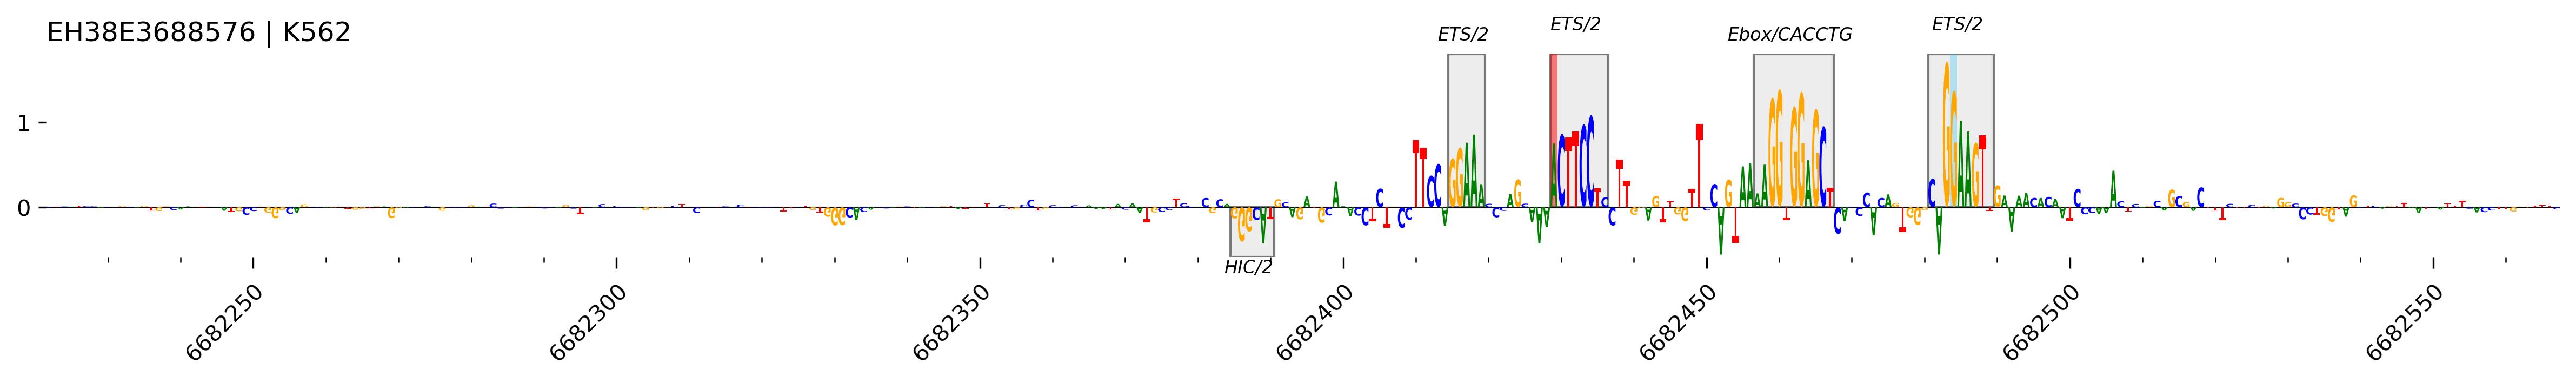

In [42]:
# EH38E3688576
# chr6:6,682,221-6,682,567
# lead Delta: 0.588637
# phenotype id: ENSG00000216863.10
# gene name: LY86-AS1
# tissue: Whole_Blood
# biotype: lncRNA
plot_specific_enhancers(
    'EH38E3688576',
    6682221,
    'chr6',
    k_mpac_collapsed_dels,
    6682429,
    [6682484],
    'K562',
    'x'
)

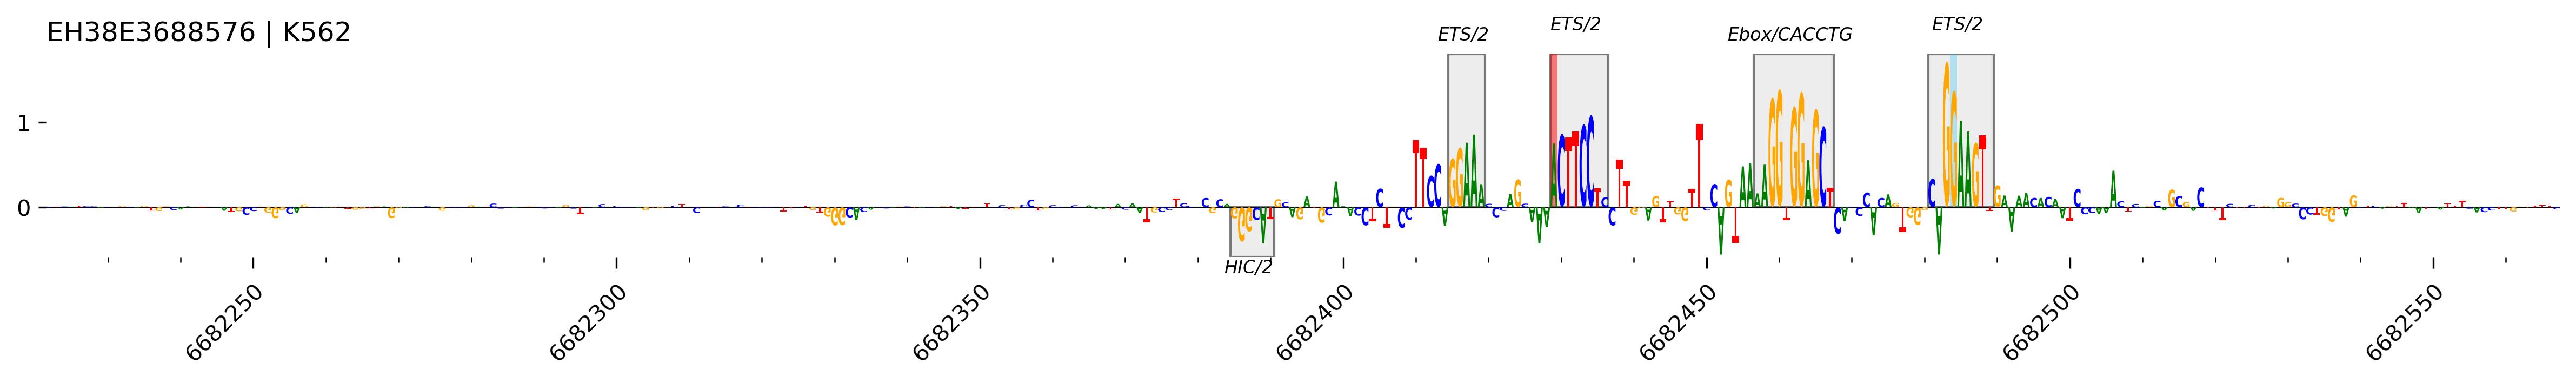

In [43]:
# EH38E3688576
# chr6:6,682,221-6,682,567
# lead Delta: 0.588637
# phenotype id: ENSG00000261211.2
# gene name: ENSG00000261211
# tissue: Whole_Blood
# biotype: lncRNA
plot_specific_enhancers(
    'EH38E3688576',
    6682221,
    'chr6',
    k_mpac_collapsed_dels,
    6682429,
    [6682484],
    'K562',
    'x'
)

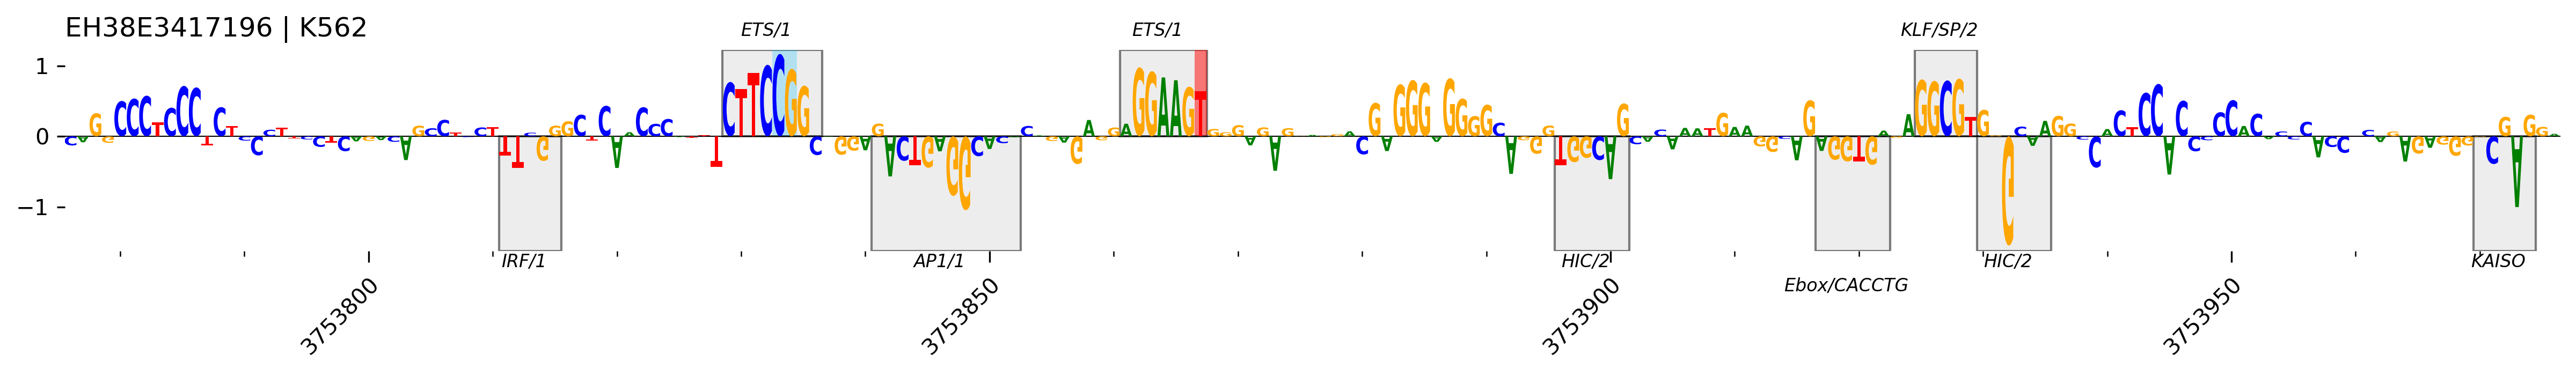

In [44]:
# EH38E3417196
# chr20:3,753,775-3,753,976
# lead Delta: 0.631590, 0.576266
# phenotype id: ENSG00000101220.18
# gene name: C20orf27
# tissue: Lung
# biotype: protein_coding
plot_specific_enhancers(
    'EH38E3417196',
    3753775,
    'chr20',
    k_mpac_collapsed_dels,
    3753867,
    [3753833, 3753834],
    'K562',
    'x'
)

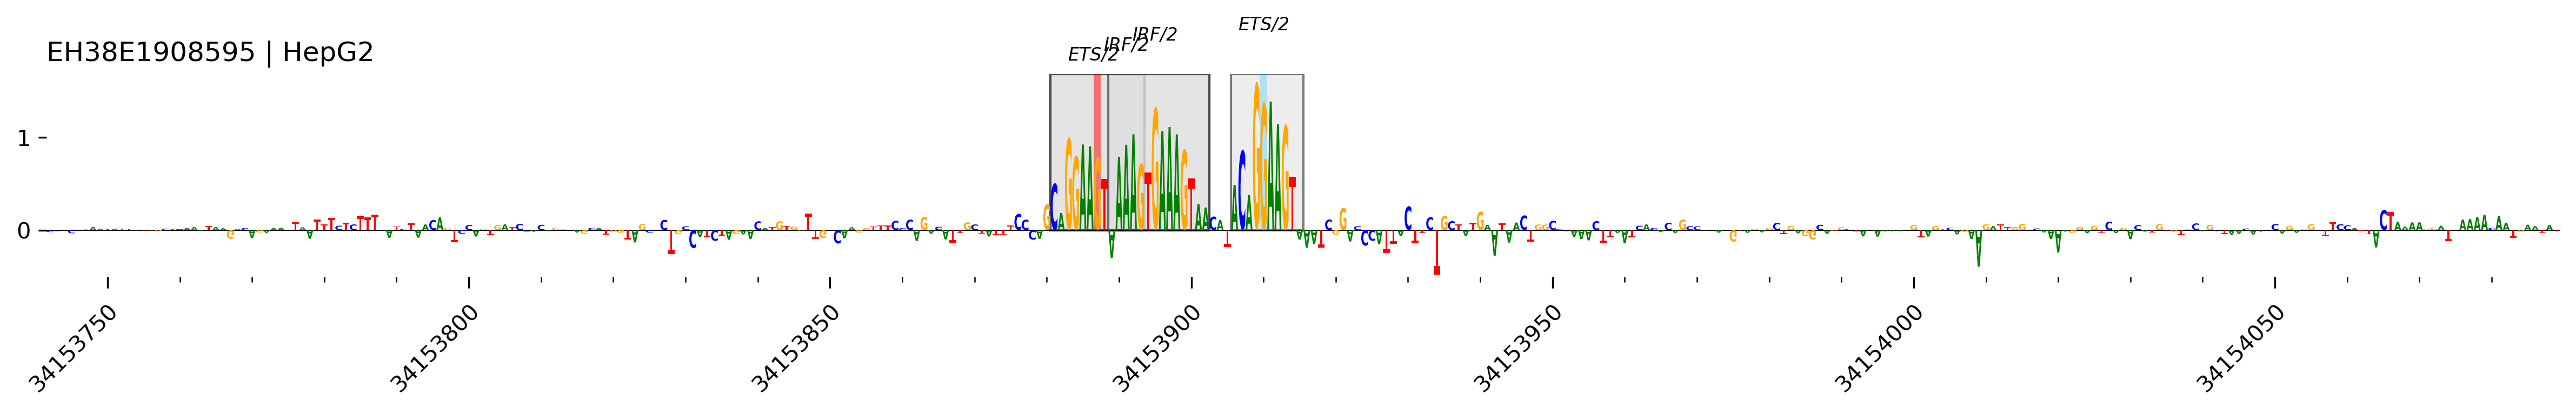

In [45]:
# EH38E1908595
# chr18:34,153,741-34,154,089
# lead Delta: 0.801511
# phenotype id: ENSG00000141431.13
# gene name: ASXL3
# tissue: Vagina
# biotype: protein_coding
plot_specific_enhancers(
    'EH38E1908595',
    34153741,
    'chr18',
    h_mpac_collapsed_dels,
    34153887,
    [34153910],
    'HepG2',
    'x'
)

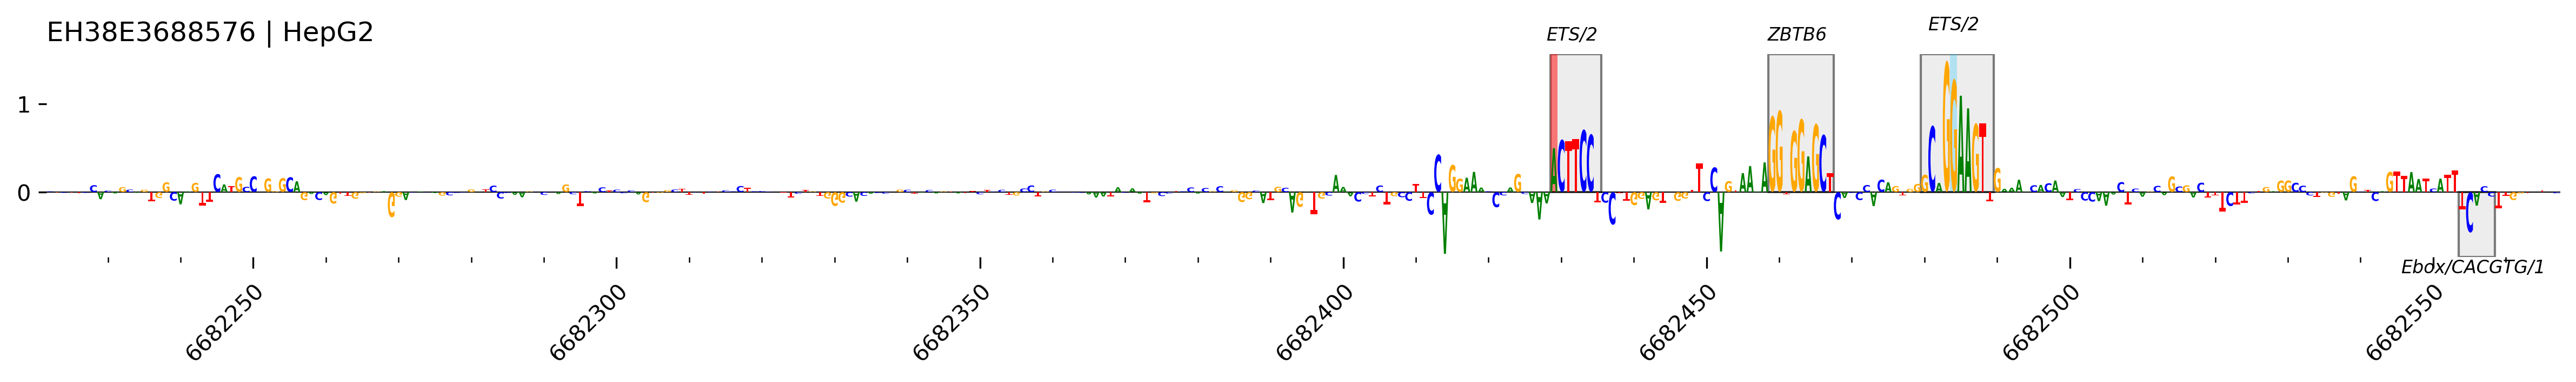

In [46]:
# EH38E3688576
# chr6:6,682,221-6,682,567
# lead Delta: 0.588637
# phenotype id: ENSG00000216863.10
# gene name: LY86-AS1
# tissue: Whole_Blood
# biotype: lncRNA
plot_specific_enhancers(
    'EH38E3688576',
    6682221,
    'chr6',
    h_mpac_collapsed_dels,
    6682429,
    [6682484],
    'HepG2',
    'x'
)

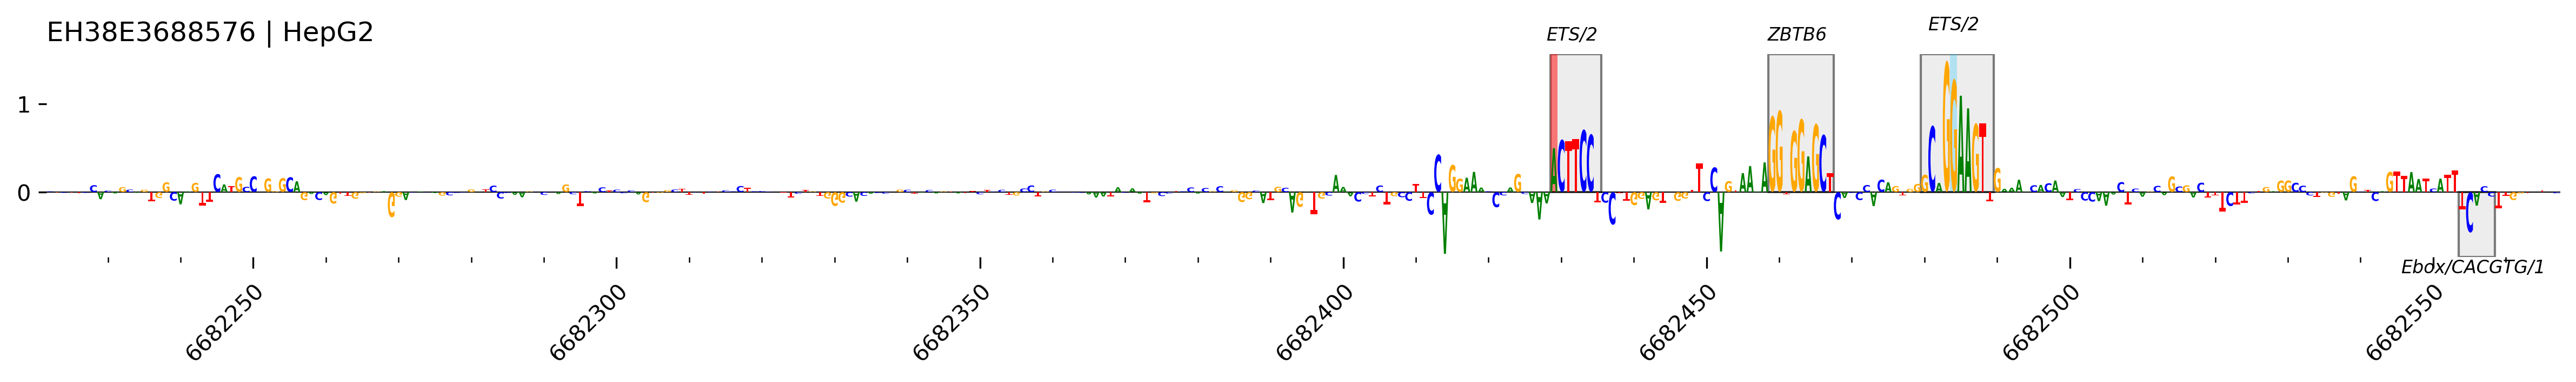

In [47]:
# EH38E3688576
# chr6:6,682,221-6,682,567
# lead Delta: 0.588637
# phenotype id: ENSG00000261211.2
# gene name: ENSG00000261211
# tissue: Whole_Blood
# biotype: lncRNA
plot_specific_enhancers(
    'EH38E3688576',
    6682221,
    'chr6',
    h_mpac_collapsed_dels,
    6682429,
    [6682484],
    'HepG2',
    'x'
)

In [48]:
### K562 MEDIUM DELTA (delta > 0.2 and < 0.5) ###

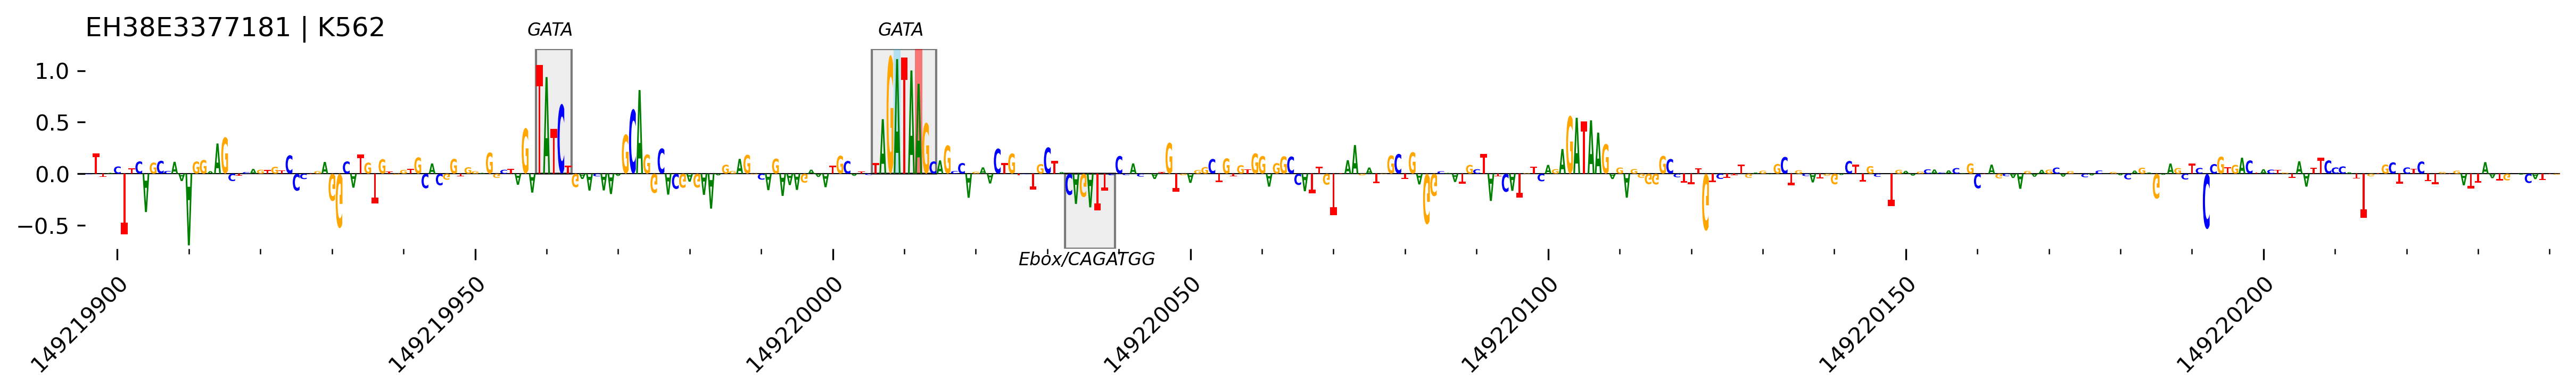

In [49]:
# EH38E3377181 GWAS variant
# chr2:149,219,895-149,220,241
# mid delta lead variant
# identified in K562
# GATA motif
# 'Bone mineral density mean'
plot_specific_enhancers(
    'EH38E3377181',
    149219895,
    'chr2',
    k_mpac_collapsed_dels,
    149220012,
    [149220009],
    'K562',
    'x'
)